# Proyecto Modelos Estadísticos Lineales
#### Pablo Ortega y Juan Sebastián Suescún

## 1) Importar librerías y datos

Cargar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

# Modelado: GLM con familia Bernoulli y enlace logit, mas pruebas de diagnostico
import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset

# Metricas de clasificacion: tasas, balanceadas, probabilisticas y curvas
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve

print('Librerías importadas correctamente')

Librerías importadas correctamente


Importar datos

In [2]:
from pathlib import Path

ruta_datos = Path.cwd() / "brain_stroke.csv"
if not ruta_datos.exists():
    for carpeta in [Path.cwd(), *Path.cwd().parents]:
        candidato = carpeta / "brain_stroke.csv"
        if candidato.exists():
            ruta_datos = candidato
            break

if not ruta_datos.exists():
    raise FileNotFoundError("No se encontró brain_stroke.csv en el directorio actual ni en sus carpetas padre.")

df = pd.read_csv(ruta_datos)

In [3]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


## 2) Preprocesamiento de datos

#### Descripción del Dataset

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4981.0,43.419859,22.662755,0.08,25.00,45.00,61.00,82.00
hypertension,4981.0,0.096165,0.294848,0.00,0.00,0.00,0.00,1.00
heart_disease,4981.0,0.055210,0.228412,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,4981.0,105.943562,45.075373,55.12,77.23,91.85,113.86,271.74
bmi,4981.0,28.498173,6.790464,14.00,23.70,28.10,32.60,48.90
stroke,4981.0,0.049789,0.217531,0.00,0.00,0.00,0.00,1.00


In [5]:
df["gender"].value_counts()

gender
Female    2907
Male      2074
Name: count, dtype: int64

In [6]:
df["hypertension"].value_counts()

hypertension
0    4502
1     479
Name: count, dtype: int64

In [7]:
df["heart_disease"].value_counts()

heart_disease
0    4706
1     275
Name: count, dtype: int64

In [8]:
df["ever_married"].value_counts()

ever_married
Yes    3280
No     1701
Name: count, dtype: int64

In [9]:
df["work_type"].value_counts()

work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64

In [10]:
df["Residence_type"].value_counts()

Residence_type
Urban    2532
Rural    2449
Name: count, dtype: int64

In [11]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64

### Revisión de desbalance de clases

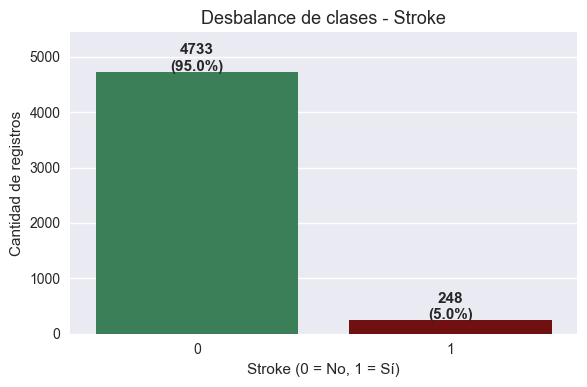

In [12]:
conteo=df["stroke"].value_counts()
class_pct = df["stroke"].value_counts(normalize=True) * 100

# Gráfica
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=conteo.index.astype(str), y=conteo.values, 
            palette=["seagreen", "maroon"], ax=ax)

# Etiquetas con conteo y porcentaje
for i, (count, pct) in enumerate(zip(conteo.values, class_pct.values)):
    ax.text(i, count + 20, f"{count}\n({pct:.1f}%)", 
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Desbalance de clases - Stroke", fontsize=13)
ax.set_xlabel("Stroke (0 = No, 1 = Sí)")
ax.set_ylabel("Cantidad de registros")
ax.set_ylim(0, conteo.max() * 1.15)

plt.tight_layout()
plt.show()


Existe un desbalance severo de la clase dependiente 95-5

### División entre categóricas y numéricas

In [13]:
# aca se convierten las columnas binarias a objeto para utilizar pd.get dummies despues en vez de hacerlo manualmente
binary_cols = ["hypertension", "heart_disease", "stroke"]
df[binary_cols] = df[binary_cols].astype("object")

In [14]:
df_num = df.select_dtypes(include=["int64", "float64"])
df_num.head()

,age,avg_glucose_level,bmi
0,67.0,228.69,36.6
1,80.0,105.92,32.5
2,49.0,171.23,34.4
3,79.0,174.12,24.0
4,81.0,186.21,29.0


In [15]:
df_cat = df.select_dtypes(include=["object"])
df_cat.drop(columns=["stroke"], inplace=True)
df_cat.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status
0,Male,0,1,Yes,Private,Urban,formerly smoked
1,Male,0,1,Yes,Private,Rural,never smoked
2,Female,0,0,Yes,Private,Urban,smokes
3,Female,1,0,Yes,Self-employed,Rural,never smoked
4,Male,0,0,Yes,Private,Urban,formerly smoked


## 3) Análisis exploratorio de datos

#### Revisión de faltantes 

In [16]:
print('Valores faltantes por variable:')
print(df.isnull().sum())
print(f'\nTotal de valores faltantes: {df.isnull().sum().sum()}')

Valores faltantes por variable:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Total de valores faltantes: 0


In [17]:
df.duplicated().sum()

np.int64(0)

No hay faltantes ni duplicados en el dataset

### 3.1) Comportamiento y relación entre predictores

#### Variables numéricas

Distribución de las variables numéricas

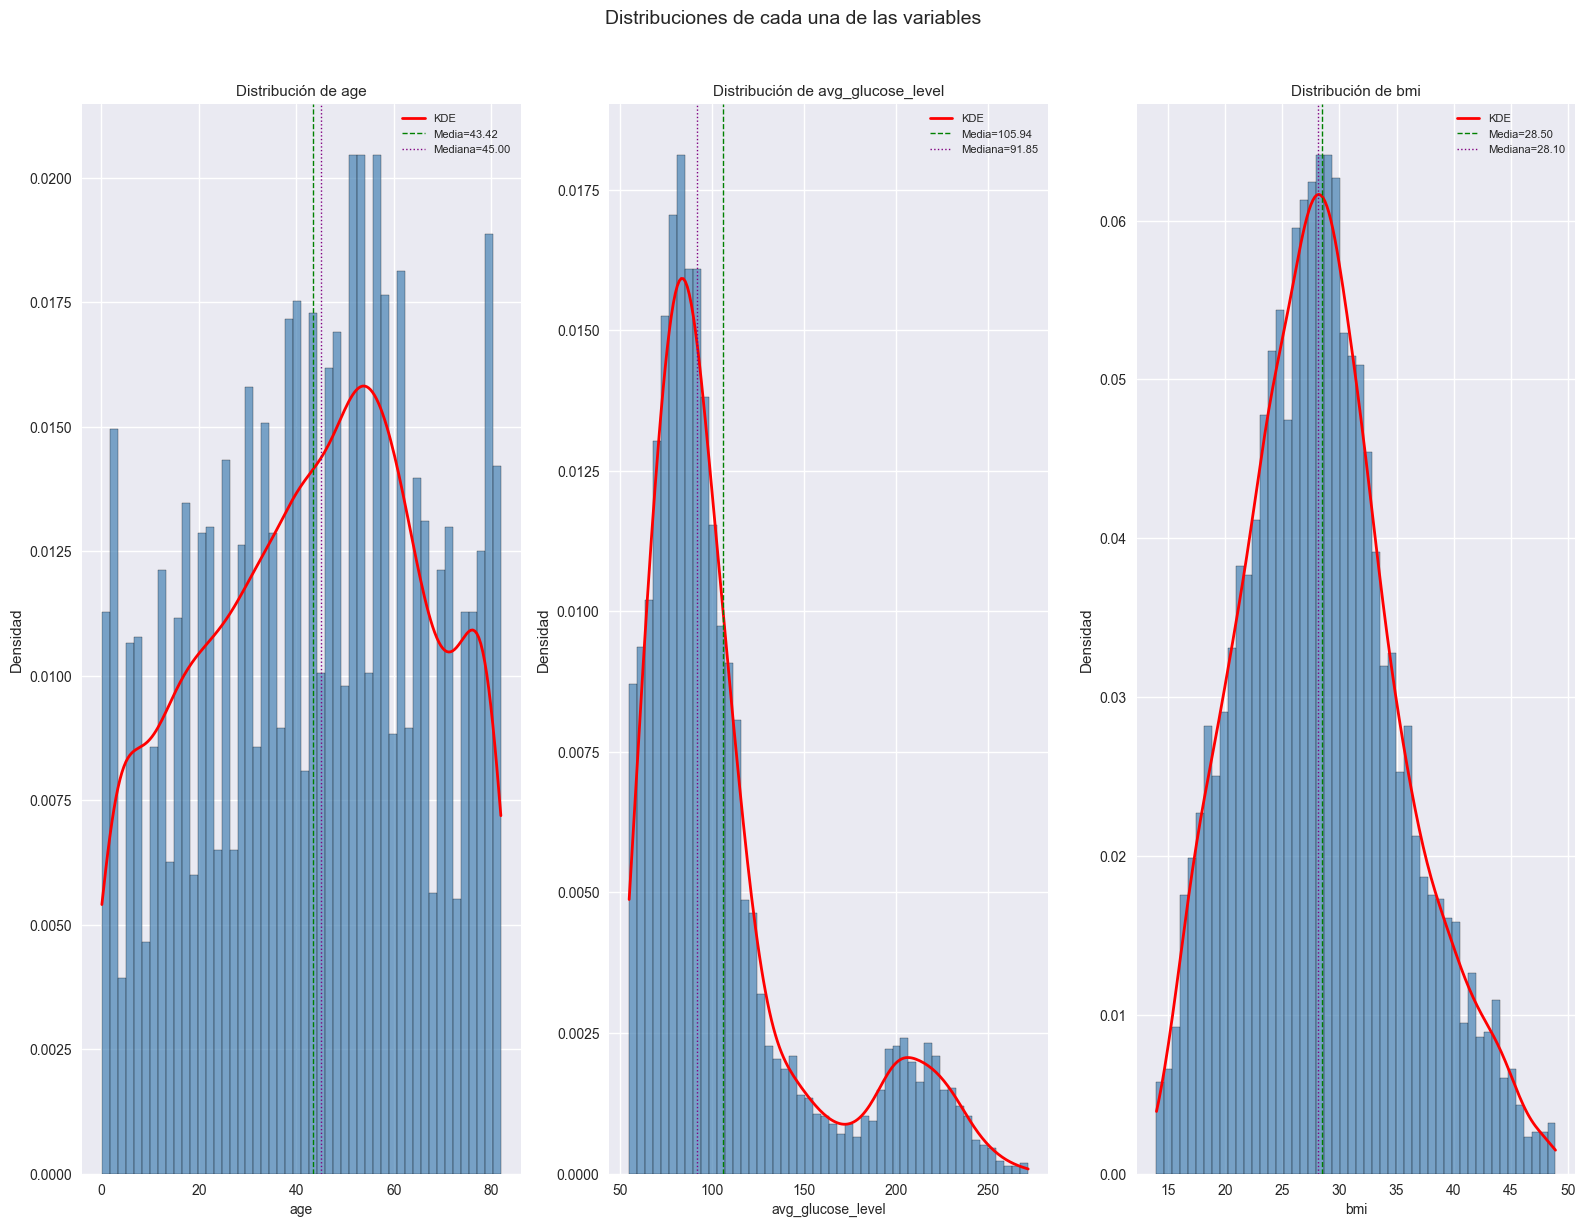

Observaciones sobre las distribuciones:
  age            : sesgo = -0.144 → simétrica
  avg_glucose_level: sesgo = +1.588 → sesgada a la derecha
  bmi            : sesgo = +0.372 → simétrica


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 12))

for i, var in enumerate(df_num.columns):
    ax = axes[i]  # ← ahora sí funciona con 2 filas
    ax.hist(df_num[var], bins=50, edgecolor='black', alpha=0.7,
            color='steelblue', density=True)

    from scipy.stats import gaussian_kde
    data = df_num[var].dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    mu = data.mean()
    med = data.median()
    ax.axvline(mu, color='green', linestyle='--', linewidth=1, label=f'Media={mu:.2f}')
    ax.axvline(med, color='purple', linestyle=':', linewidth=1, label=f'Mediana={med:.2f}')
    ax.set_title(f'Distribución de {var}', fontsize=11)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones de cada una de las variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Observaciones sobre las distribuciones:')
for var in df_num.columns:
    sk = df_num[var].skew()
    tipo = 'simétrica' if abs(sk) < 0.5 else ('sesgada a la derecha' if sk > 0 else 'sesgada a la izquierda')
    print(f'  {var:15s}: sesgo = {sk:+.3f} → {tipo}')

La distribucion de age parece uniforme. 
La distribucion de avg_glucose_level es bimodal, tiene una masa alrededor de 75–110 y otra alrededor de 180–220. Buscando una explicación para esto, podría ser por un grupo normoglucémico y otro diabetico. Se podría revisar la opción de hacer una variable categórica usando avg_glucose_level.
Por último, bmi está un poco sesgada hacia la derecha entonces podriamos revisar una transformación logarítmica.

 Aplicar logaritmo al nivel de glucosa y al BMI

In [19]:
df["log_glucose"] = np.log(df["avg_glucose_level"])
df["log_bmi"] = np.log(df["bmi"])

df_num["log_glucose"] = np.log(df_num["avg_glucose_level"])
df_num["log_bmi"] = np.log(df_num["bmi"])


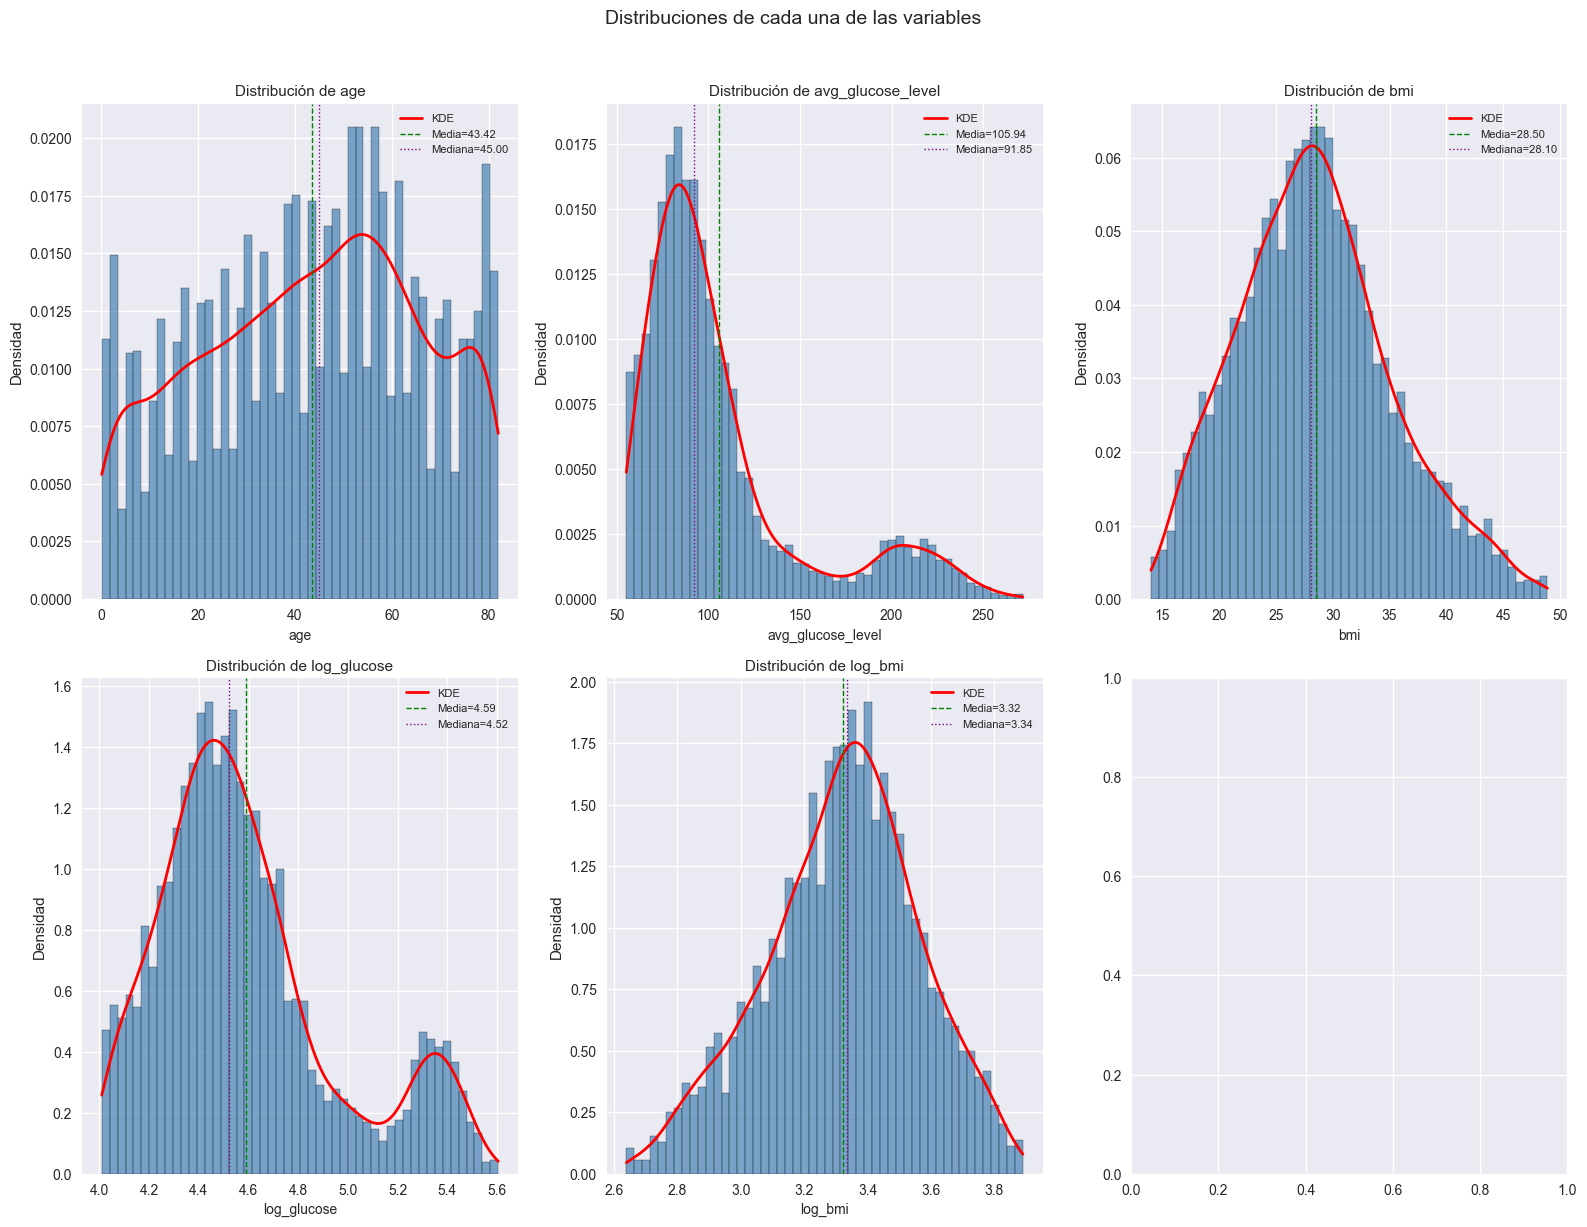

Observaciones sobre las distribuciones:
  age            : sesgo = -0.144 → simétrica
  avg_glucose_level: sesgo = +1.588 → sesgada a la derecha
  bmi            : sesgo = +0.372 → simétrica
  log_glucose    : sesgo = +0.889 → sesgada a la derecha
  log_bmi        : sesgo = -0.235 → simétrica


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

for i, var in enumerate(df_num.columns):
    ax = axes[i // 3, i % 3]  # ← ahora sí funciona con 2 filas
    ax.hist(df_num[var], bins=50, edgecolor='black', alpha=0.7,
            color='steelblue', density=True)

    from scipy.stats import gaussian_kde
    data = df_num[var].dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    mu = data.mean()
    med = data.median()
    ax.axvline(mu, color='green', linestyle='--', linewidth=1, label=f'Media={mu:.2f}')
    ax.axvline(med, color='purple', linestyle=':', linewidth=1, label=f'Mediana={med:.2f}')
    ax.set_title(f'Distribución de {var}', fontsize=11)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)


plt.suptitle('Distribuciones de cada una de las variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Observaciones sobre las distribuciones:')
for var in df_num.columns:
    sk = df_num[var].skew()
    tipo = 'simétrica' if abs(sk) < 0.5 else ('sesgada a la derecha' if sk > 0 else 'sesgada a la izquierda')
    print(f'  {var:15s}: sesgo = {sk:+.3f} → {tipo}')

La transformación logarítmica reduce ligeramente la cola derecha de glucose, pero no elimina la bimodalidad; por eso, no parece justificado aplicarla. En el caso de bmi, la transformación logarítmica mejora un poco la simetría, pero no lo suficiente como para compensar el cambio, así que tampoco conviene conservarla.

Quitar logaritmos

In [21]:
df_num.drop(columns=["log_glucose", "log_bmi"], inplace=True)
df.drop(columns=["log_glucose", "log_bmi"], inplace=True)

Detección de outliers

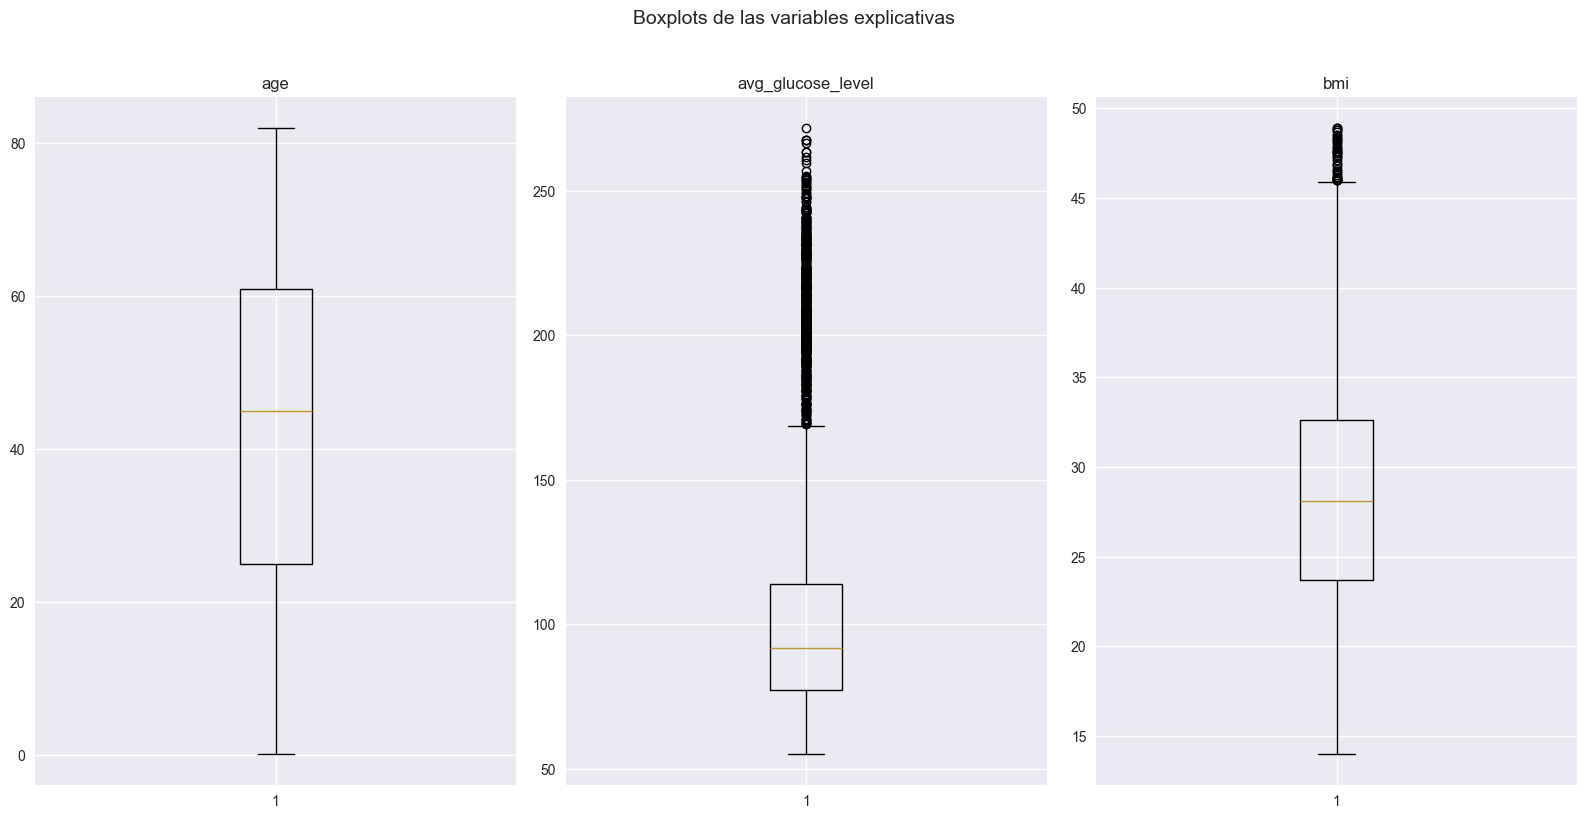

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8), squeeze=False)
variables = [c for c in df_num.columns]
for i, var in enumerate(variables):
    ax = axes[0,i]  # fila 0, columna i
    ax.boxplot(df_num[var], vert=True)
    ax.set_title(var)

plt.suptitle('Boxplots de las variables explicativas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Las tres variables presentan outliers en el extremo superior, especialmente avg_glucose_level (cola larga de pacientes diabéticos) y bmi (obesidad). No se eliminan: son valores clínicamente plausibles y probablemente enriquecidos en el grupo stroke=1, por lo que removerlos sesgaría el análisis.

Pair plot de las variables

Generando pairplot (puede tomar unos segundos)...


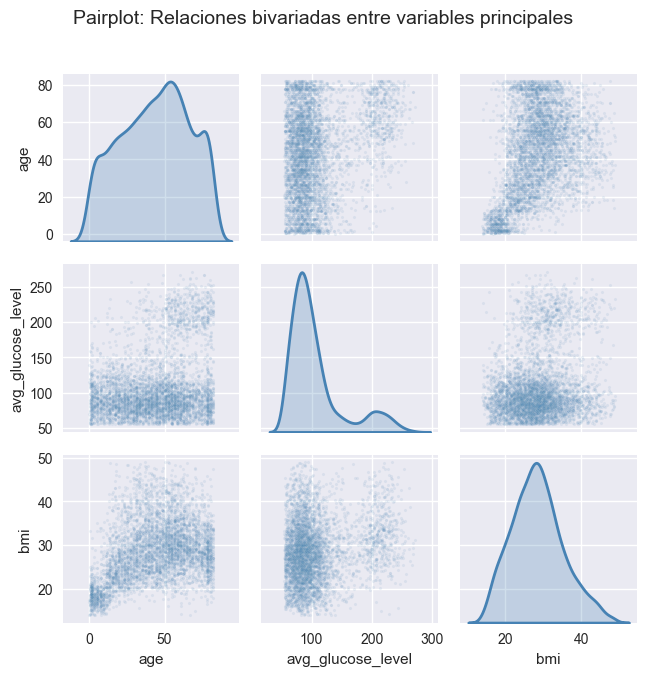

In [23]:
vars_pairplot = df_num.columns.tolist()
print('Generando pairplot (puede tomar unos segundos)...')
g = sns.pairplot(df[vars_pairplot], 
                 diag_kind='kde',
                 plot_kws={'alpha': 0.1, 's': 5, 'color': 'steelblue'},
                 diag_kws={'color': 'steelblue', 'linewidth': 2},
                 height=2.2, aspect=1)
g.figure.suptitle('Pairplot: Relaciones bivariadas entre variables principales', 
                   fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Correlaciones

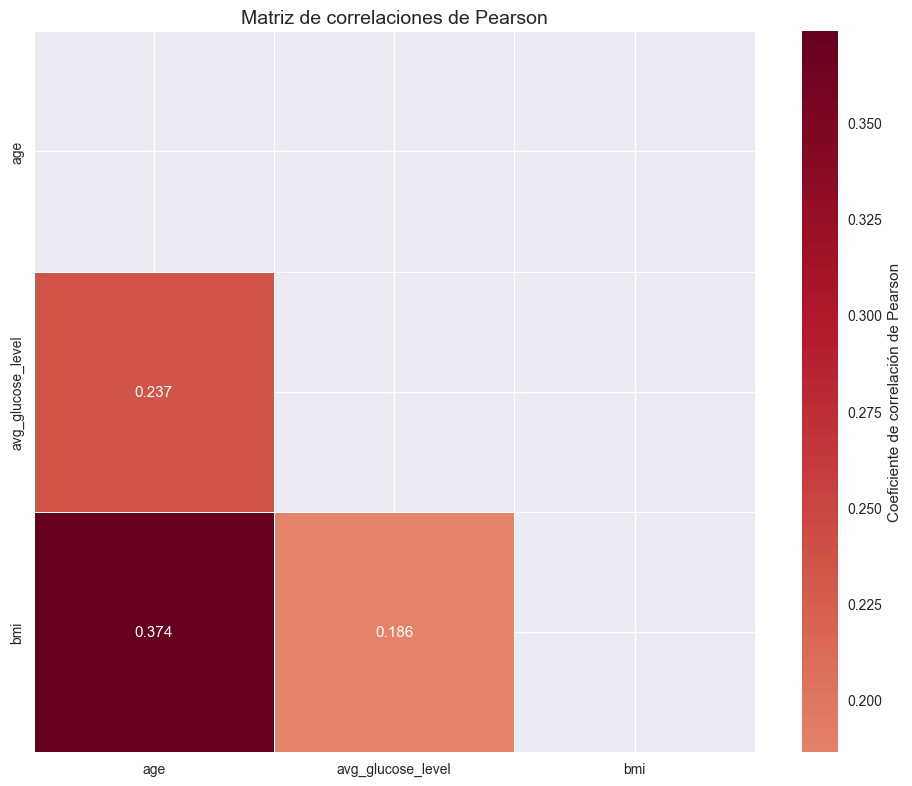

In [24]:
vars_corr = df_num.columns.tolist()

corr_matrix = df[vars_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Coeficiente de correlación de Pearson'})
ax.set_title('Matriz de correlaciones de Pearson', fontsize=14)
plt.tight_layout()
plt.show()


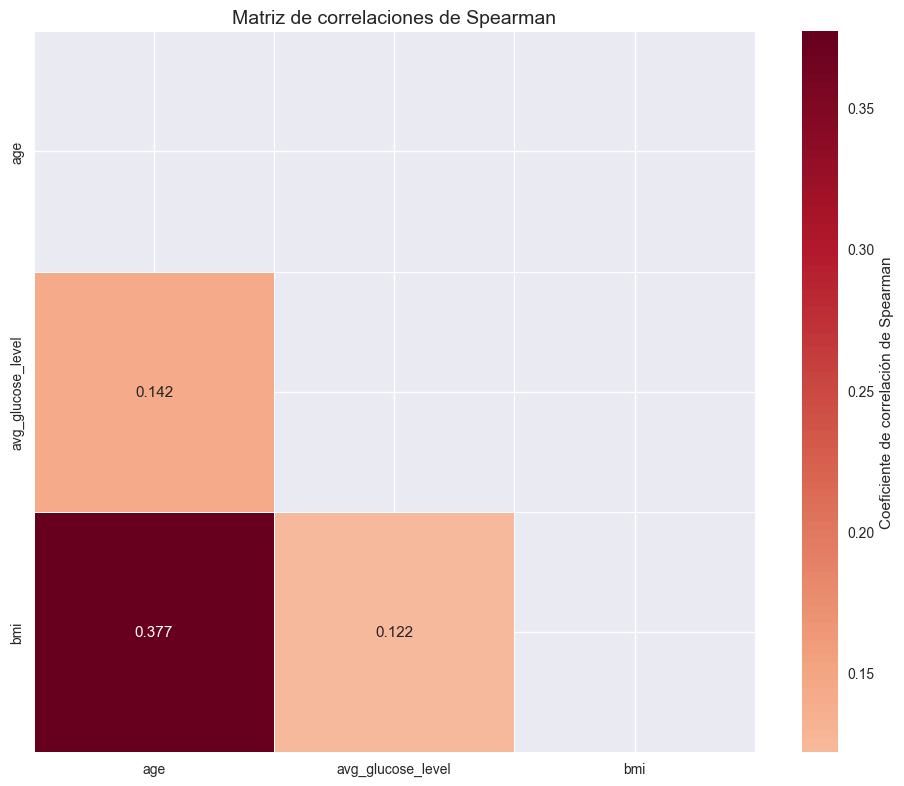

In [25]:


vars_corr = df_num.columns.tolist()

corr_matrix = df[vars_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Coeficiente de correlación de Spearman'})
ax.set_title('Matriz de correlaciones de Spearman', fontsize=14)
plt.tight_layout()
plt.show()


Las correlaciones lineales entre las tres variables continuas son débiles en Pearson y Spearman. La correlación más notable es age-bmi (0.38), consistente con el aumento de masa corporal con la edad. Spearman no difiere sustancialmente de Pearson, lo que indica que las relaciones, aunque débiles, son aproximadamente monótonas. No hay indicios de colinealidad entre los predictores numéricos.

Multicolinealidad: VIF sobre la matriz de diseño con dummies

In [26]:
# VIF (Variance Inflation Factor). Regla práctica: VIF>5 sospechoso, >10 problemático.
# Se calcula sobre el diseño completo (continuas + dummies), excluyendo stroke.

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns="stroke").copy()
X_vif_enc = pd.get_dummies(X_vif, drop_first=True).astype(float)
X_vif_enc.insert(0, "Intercept", 1.0)

vif_df = pd.DataFrame({
    "variable": X_vif_enc.columns,
    "VIF": [variance_inflation_factor(X_vif_enc.values, i)
            for i in range(X_vif_enc.shape[1])]
}).sort_values("VIF", ascending=False)

# El VIF del intercepto no es interpretable, se omite del comentario
print(vif_df[vif_df["variable"] != "Intercept"].to_string(index=False))


                      variable      VIF
            work_type_children 3.251545
                           age 2.846678
             work_type_Private 2.349190
              ever_married_Yes 1.977037
       work_type_Self-employed 1.937237
   smoking_status_never smoked 1.802836
smoking_status_formerly smoked 1.606523
         smoking_status_smokes 1.541746
                           bmi 1.375993
               heart_disease_1 1.116232
                hypertension_1 1.115732
             avg_glucose_level 1.111078
                   gender_Male 1.029246
          Residence_type_Urban 1.002276


Ningún predictor supera VIF=5. La columna con mayor VIF es work_type_children, lo cual era esperable porque está fuertemente asociada con edades bajas. No hay evidencia de multicolinealidad severa que comprometa la estimación.


#### Variables categóricas

Distribución de las variables

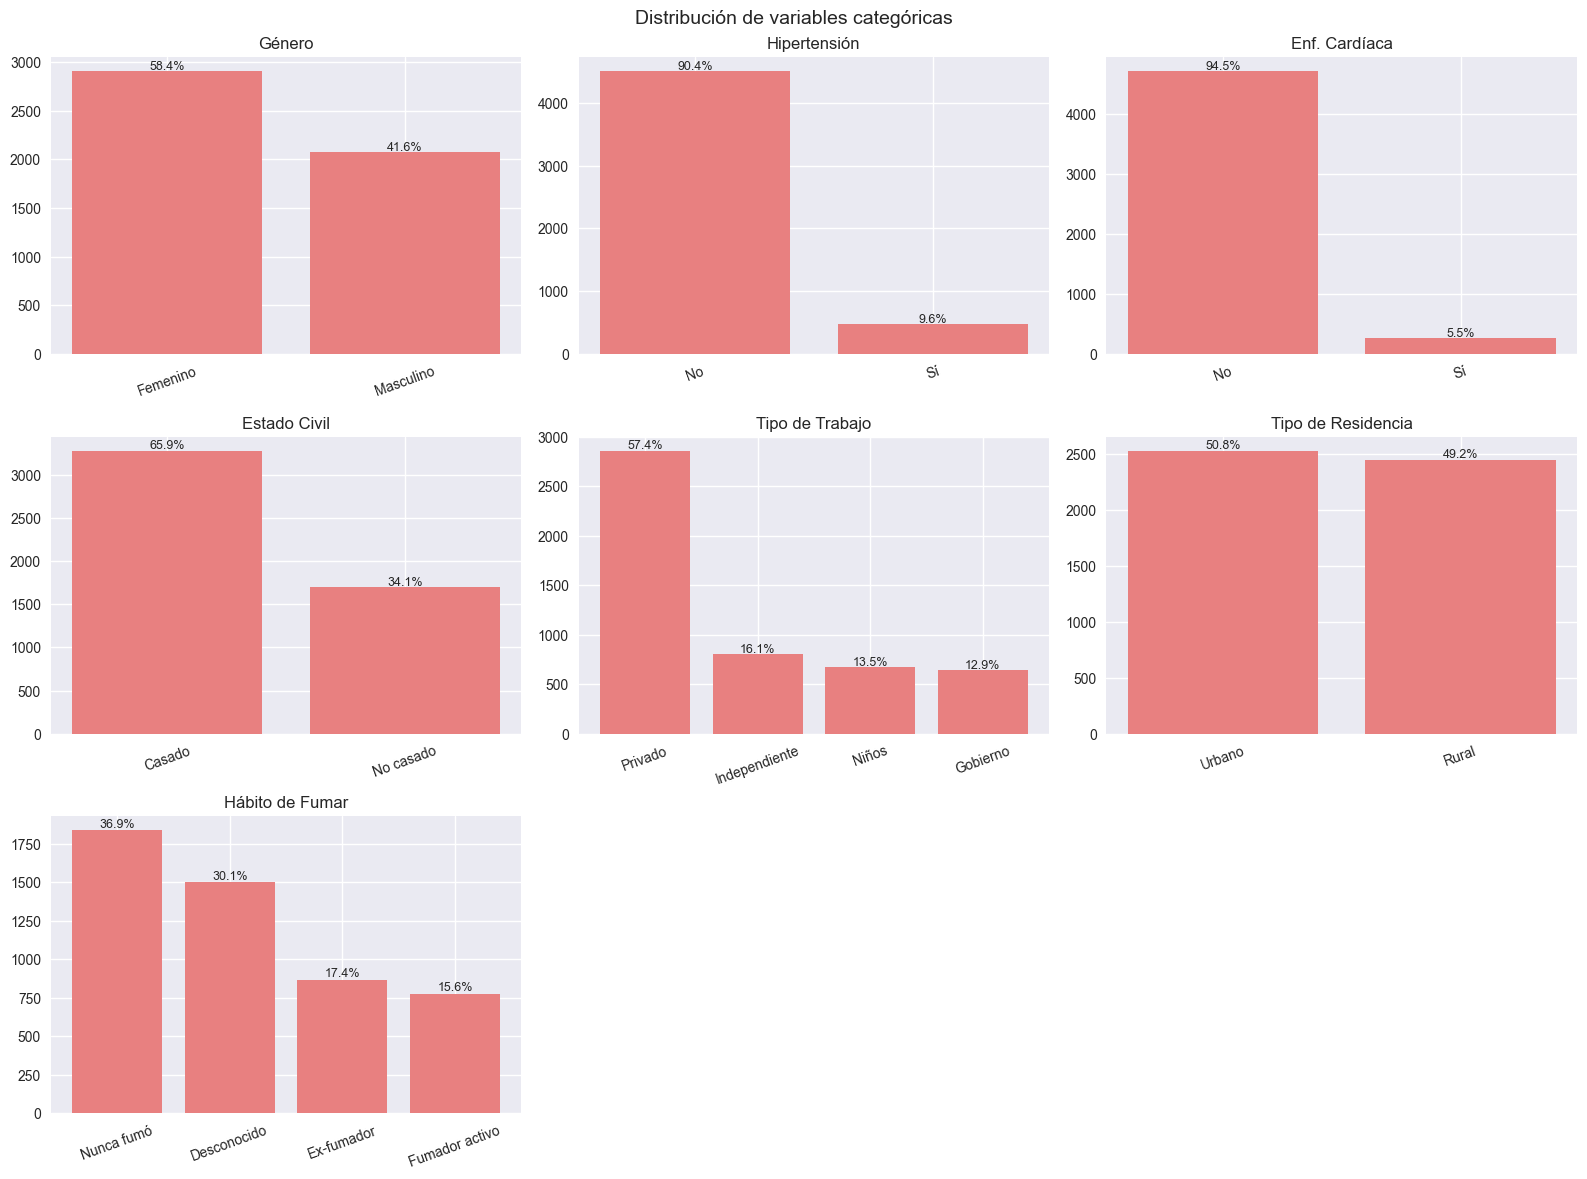

In [27]:
etiquetas = {
    "gender":         ("Género",           {"Female": "Femenino", "Male": "Masculino"}),
    "hypertension":   ("Hipertensión",      {0: "No", 1: "Sí"}),
    "heart_disease":  ("Enf. Cardíaca",     {0: "No", 1: "Sí"}),
    "ever_married":   ("Estado Civil",      {"Yes": "Casado", "No": "No casado"}),
    "work_type":      ("Tipo de Trabajo",   {"Private": "Privado", "Self-employed": "Independiente",
                                             "Govt_job": "Gobierno", "children": "Niños"}),
    "Residence_type": ("Tipo de Residencia",  {"Urban": "Urbano", "Rural": "Rural"}),
    "smoking_status": ("Hábito de Fumar",   {"formerly smoked": "Ex-fumador",
                                             "never smoked": "Nunca fumó",
                                             "smokes": "Fumador activo",
                                             "Unknown": "Desconocido"})
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Distribución de variables categóricas", fontsize=14)

for ax, (col, (titulo, mapa)) in zip(axes.flatten(), etiquetas.items()):
    temp = df[col].map(mapa) if mapa else df[col]
    conteos = temp.value_counts()
    proporciones = conteos / conteos.sum() * 100
    ax.bar(conteos.index, conteos.values, color="#E88080")
    for i, (v, p) in enumerate(zip(conteos.values, proporciones.values)):
        ax.text(i, v + 20, f"{p:.1f}%", ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

Relación entre las variables categóricas

In [28]:
pd.crosstab(
    df['smoking_status'],
    df['hypertension'],
    normalize='index'
) * 100


hypertension,0,1
smoking_status,,
Unknown,96.666667,3.333333
formerly smoked,86.735871,13.264129
never smoked,87.867247,12.132753
smokes,88.273196,11.726804


In [29]:
pd.crosstab(
    df['smoking_status'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
smoking_status,,
Unknown,96.800000,3.200000
formerly smoked,91.118800,8.881200
never smoked,95.157780,4.842220
smokes,92.139175,7.860825


In [30]:
pd.crosstab(
    df['hypertension'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
hypertension,,
0,95.313194,4.686806
1,86.638831,13.361169


In [31]:
pd.crosstab(
    df['gender'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
gender,,
Female,96.147231,3.852769
Male,92.140791,7.859209


In [32]:
pd.crosstab(
    df['gender'],
    df['smoking_status'],
    normalize='index'
) * 100

smoking_status,Unknown,formerly smoked,never smoked,smokes
gender,,,,
Female,27.794978,15.961472,41.073271,15.170279
Male,33.365477,19.431051,31.051109,16.152363


In [33]:
pd.crosstab(
    df['gender'],
    df['hypertension'],
    normalize='index'
) * 100

hypertension,0,1
gender,,
Female,90.918473,9.081527
Male,89.633558,10.366442


In [34]:
pd.crosstab(
    df['ever_married'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
ever_married,,
No,98.118754,1.881246
Yes,92.591463,7.408537


#### Relación entre numéricas y categóricas

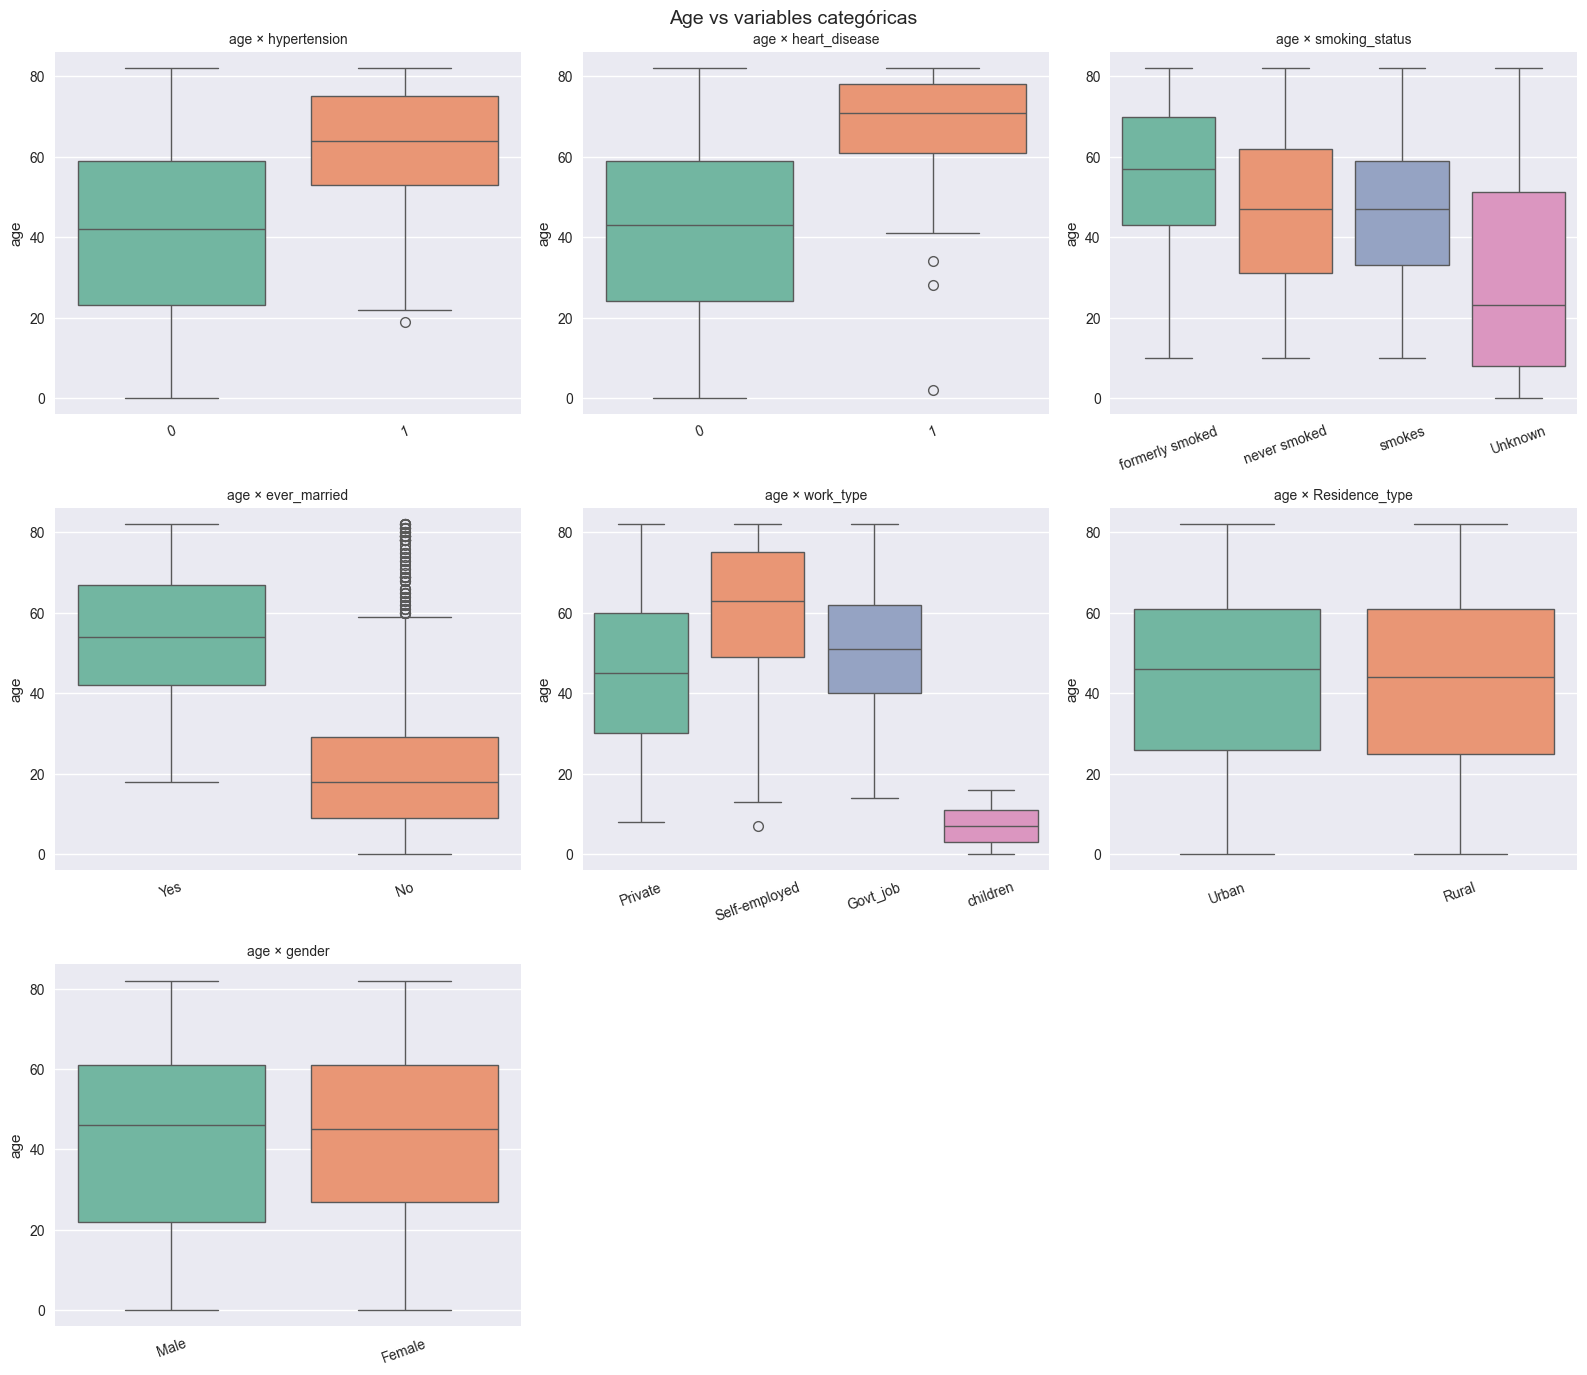

In [35]:
combos_age = [
    ("age", "hypertension"),
    ("age", "heart_disease"),
    ("age", "smoking_status"),
    ("age", "ever_married"),
    ("age", "work_type"),
    ("age", "Residence_type"),
    ("age", "gender"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Age vs variables categóricas", fontsize=14)

for ax, (num, cat) in zip(axes.flatten(), combos_age):
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × {cat}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

# Ocultar subplots sobrantes
axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

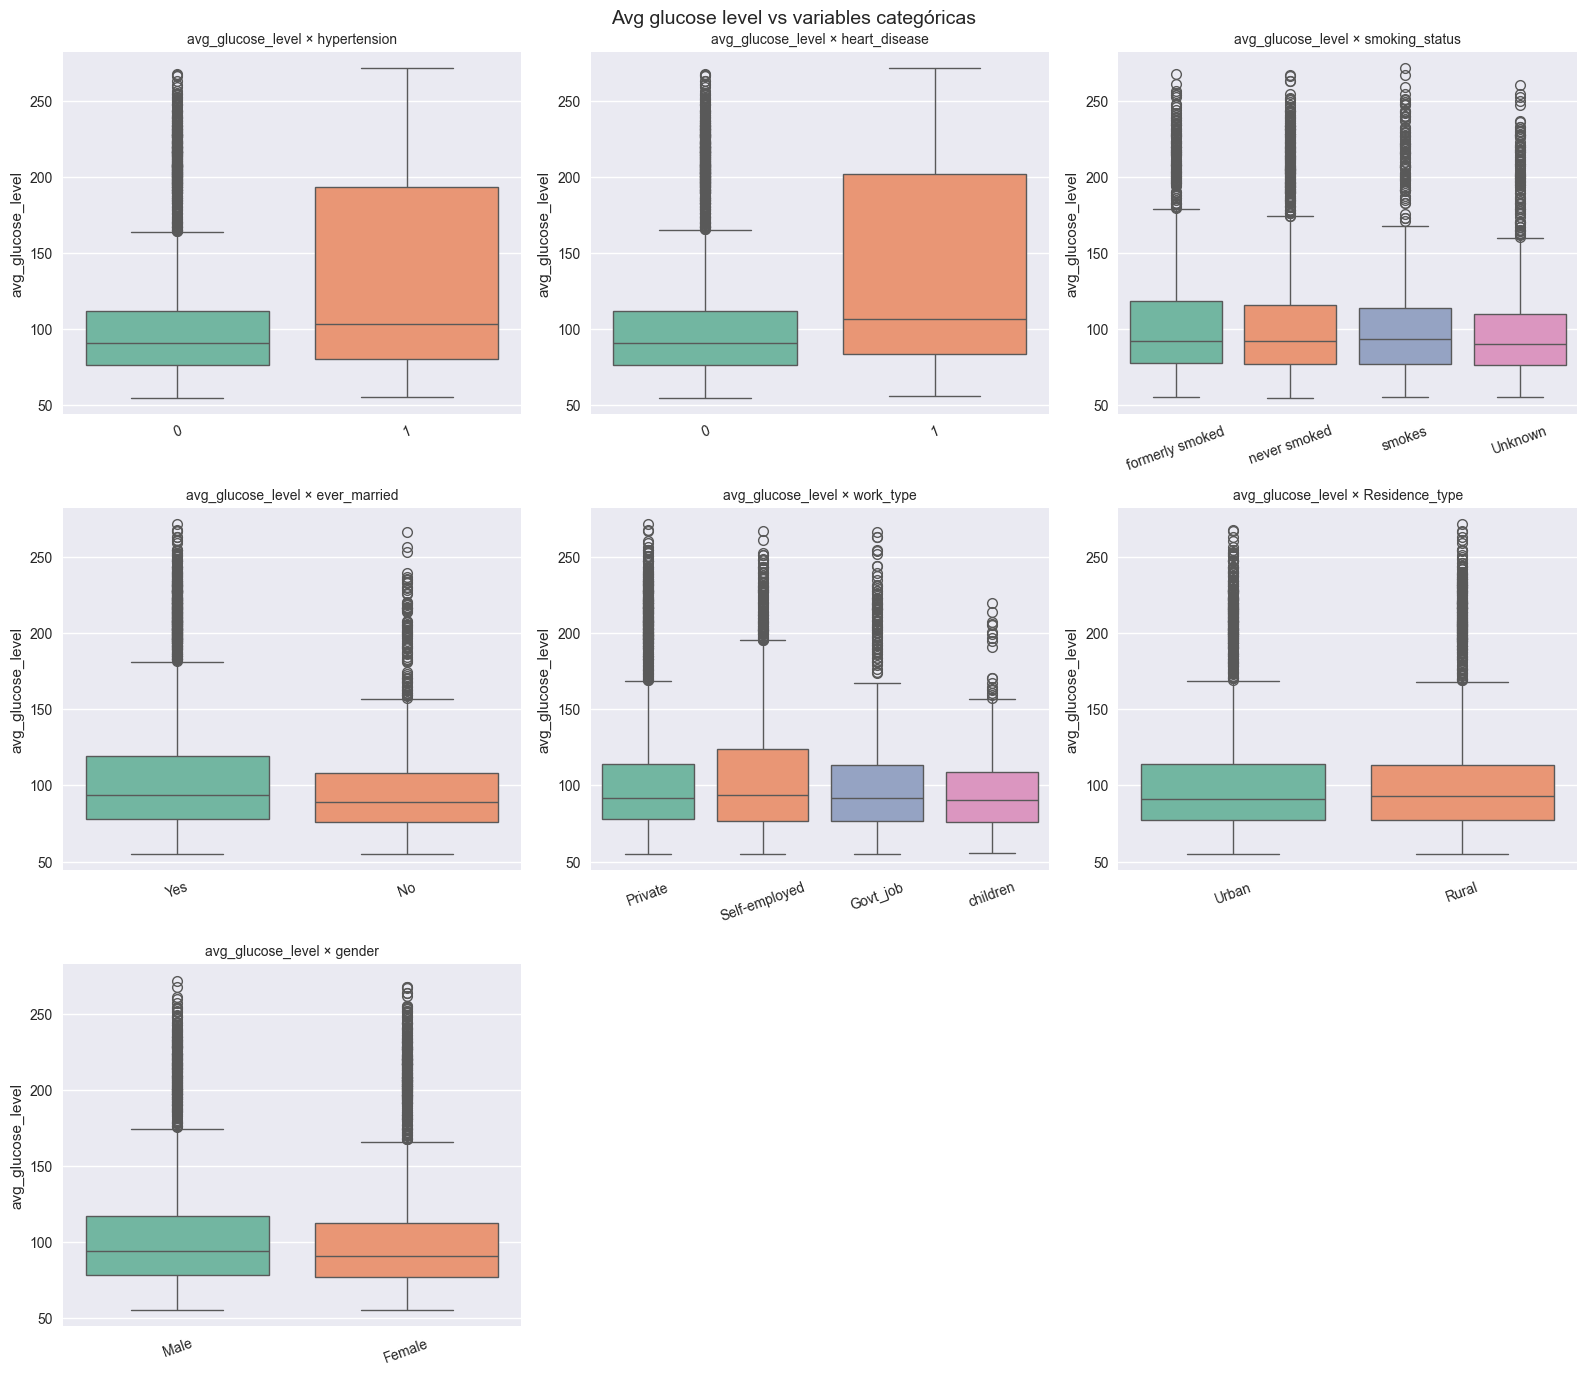

In [36]:
combos_glucose = [
    ("avg_glucose_level", "hypertension"),
    ("avg_glucose_level", "heart_disease"),
    ("avg_glucose_level", "smoking_status"),
    ("avg_glucose_level", "ever_married"),
    ("avg_glucose_level", "work_type"),
    ("avg_glucose_level", "Residence_type"),
    ("avg_glucose_level", "gender"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Avg glucose level vs variables categóricas", fontsize=14)

for ax, (num, cat) in zip(axes.flatten(), combos_glucose):
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × {cat}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()


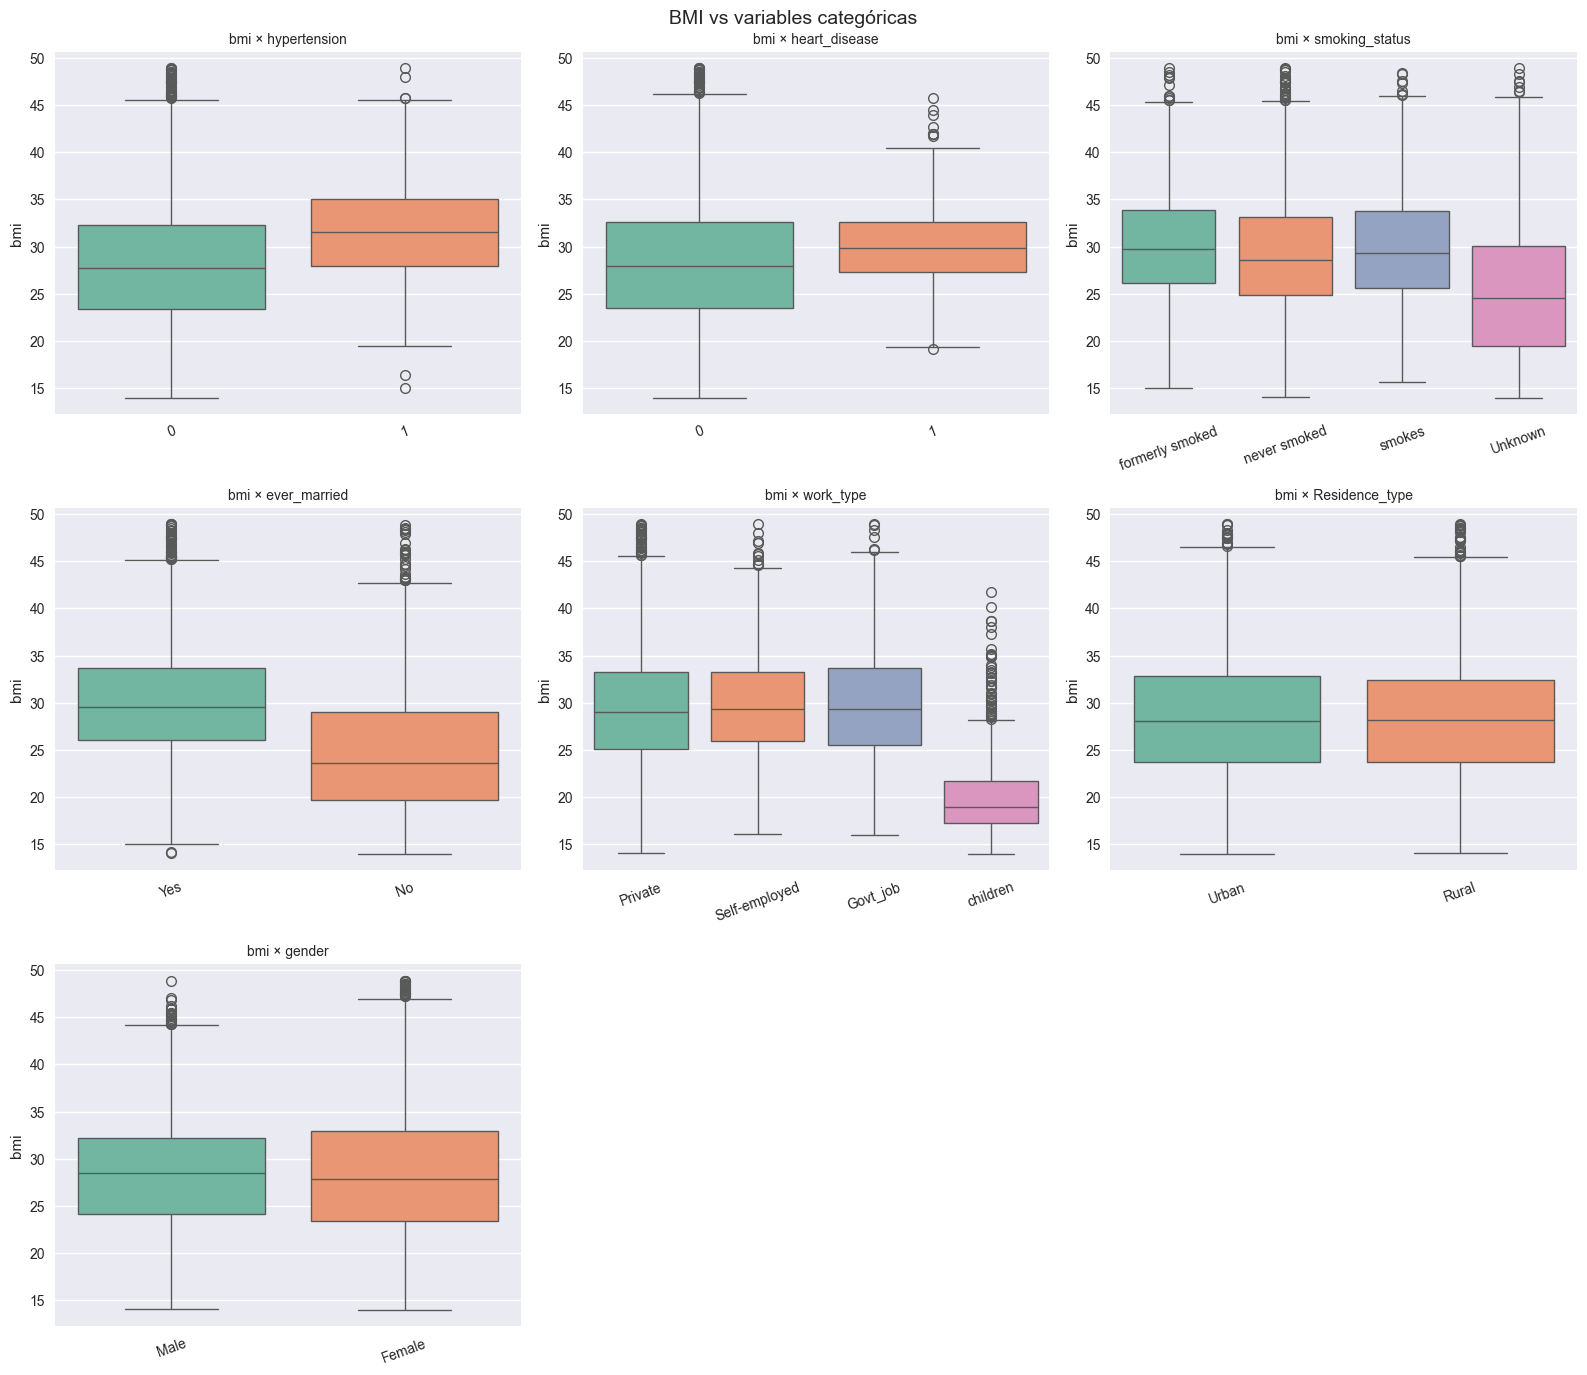

In [37]:
combos_bmi = [
    ("bmi", "hypertension"),
    ("bmi", "heart_disease"),
    ("bmi", "smoking_status"),
    ("bmi", "ever_married"),
    ("bmi", "work_type"),
    ("bmi", "Residence_type"),
    ("bmi", "gender"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("BMI vs variables categóricas", fontsize=14)

for ax, (num, cat) in zip(axes.flatten(), combos_bmi):
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × {cat}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

Los patrones esperados se confirman: age aumenta con hypertension, heart_disease, ever_married. avg_glucose_level es mayor en hipertensos y con enfermedad cardíaca, consistente con el perfil cardiometabólico. bmi muestra diferencias menores entre grupos, salvo el descenso esperado en children. Estas asociaciones anticipan posibles efectos de confusión por edad que el modelo deberá controlar.

In [38]:
import itertools

categoricas = ["gender", "hypertension", "heart_disease", 
               "ever_married", "work_type", "Residence_type", "smoking_status"]

pares = list(itertools.combinations(categoricas, 2))

for var1, var2 in pares:
    print(f"--- {var1} × {var2} ---")
    tabla = pd.crosstab(df[var1], df[var2], normalize="index").mul(100).round(1)
    print(tabla)
    print()

--- gender × hypertension ---
hypertension     0     1
gender                  
Female        90.9   9.1
Male          89.6  10.4

--- gender × heart_disease ---
heart_disease     0    1
gender                  
Female         96.1  3.9
Male           92.1  7.9

--- gender × ever_married ---
ever_married    No   Yes
gender                  
Female        33.0  67.0
Male          35.8  64.2

--- gender × work_type ---
work_type  Govt_job  Private  Self-employed  children
gender                                               
Female         13.4     58.6           17.1      10.9
Male           12.2     55.7           14.9      17.2

--- gender × Residence_type ---
Residence_type  Rural  Urban
gender                      
Female           49.0   51.0
Male             49.4   50.6

--- gender × smoking_status ---
smoking_status  Unknown  formerly smoked  never smoked  smokes
gender                                                        
Female             27.8             16.0          41.1 

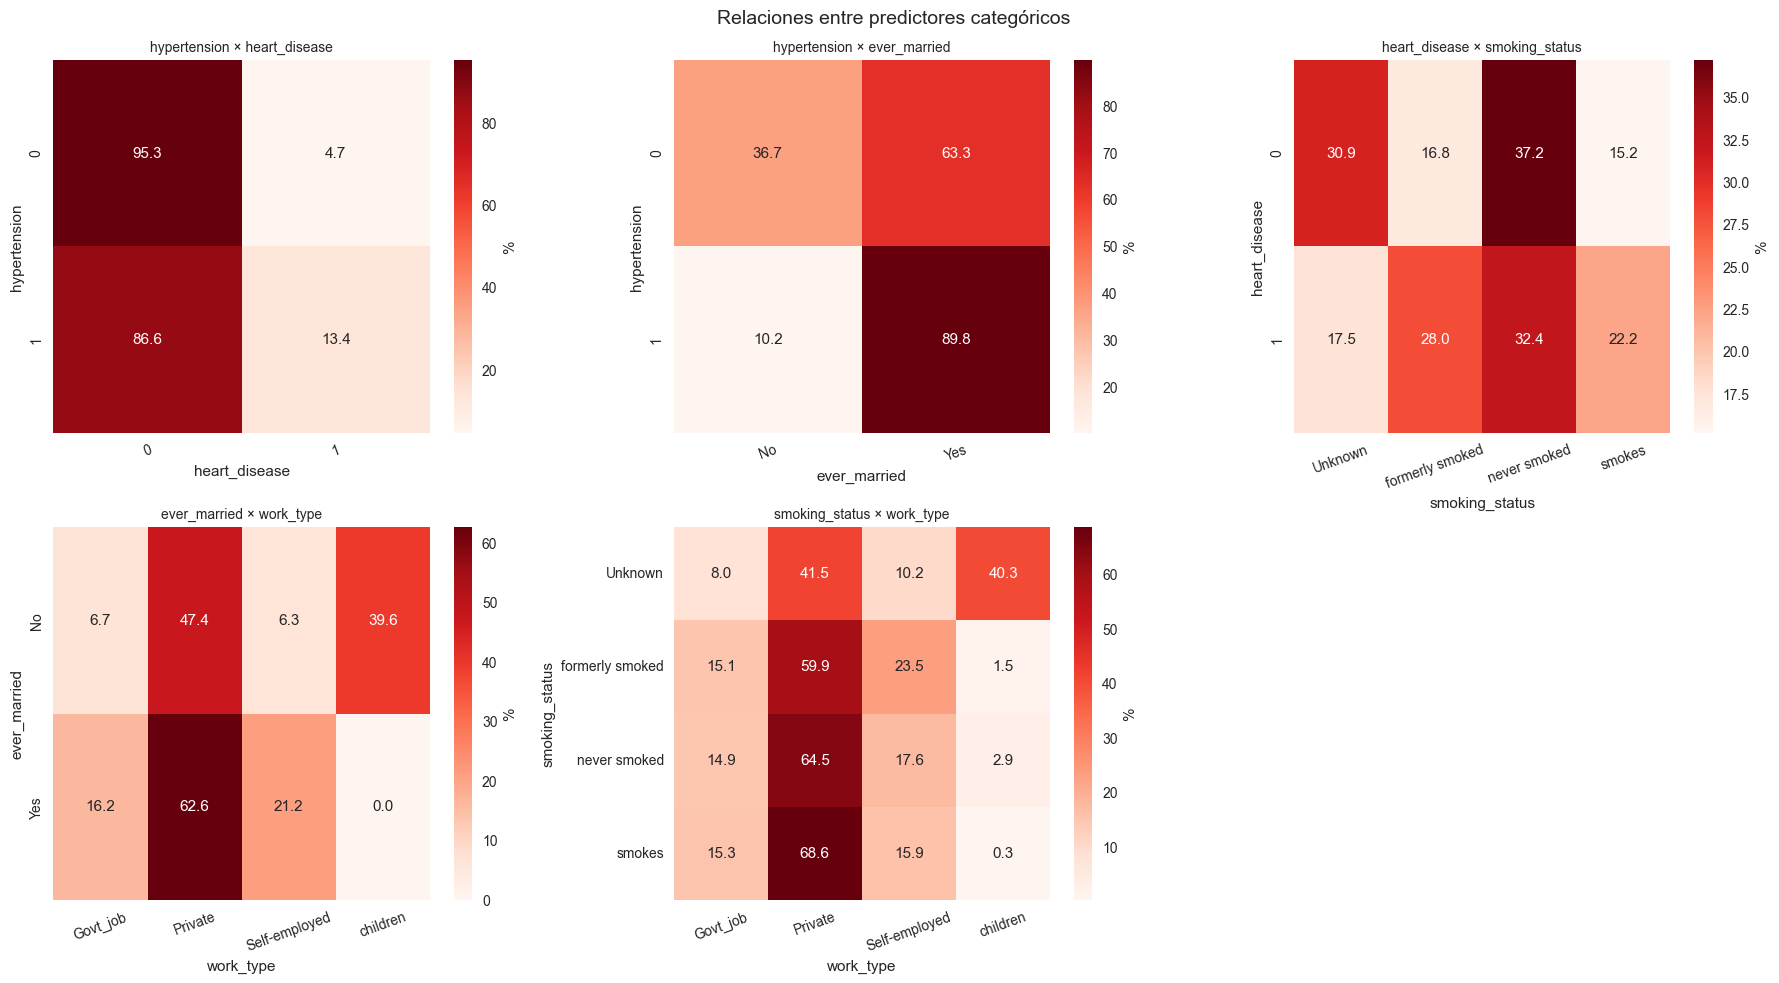

In [39]:
pares_relevantes = [
    ("hypertension", "heart_disease"),
    ("hypertension", "ever_married"),
    ("heart_disease", "smoking_status"),
    ("ever_married", "work_type"),
    ("smoking_status","work_type"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Relaciones entre predictores categóricos", fontsize=14)

for ax, (var1, var2) in zip(axes.flatten(), pares_relevantes):
    tabla = pd.crosstab(df[var1], df[var2], normalize="index").mul(100).round(1)
    sns.heatmap(tabla, annot=True, fmt=".1f", cmap="Reds", ax=ax,
                cbar_kws={"label": "%"})
    ax.set_title(f"{var1} × {var2}", fontsize=10)
    ax.tick_params(axis='x', rotation=20)

axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

### 3.2) Relación de los predictores con la variable de interés

#### Variables numéricas

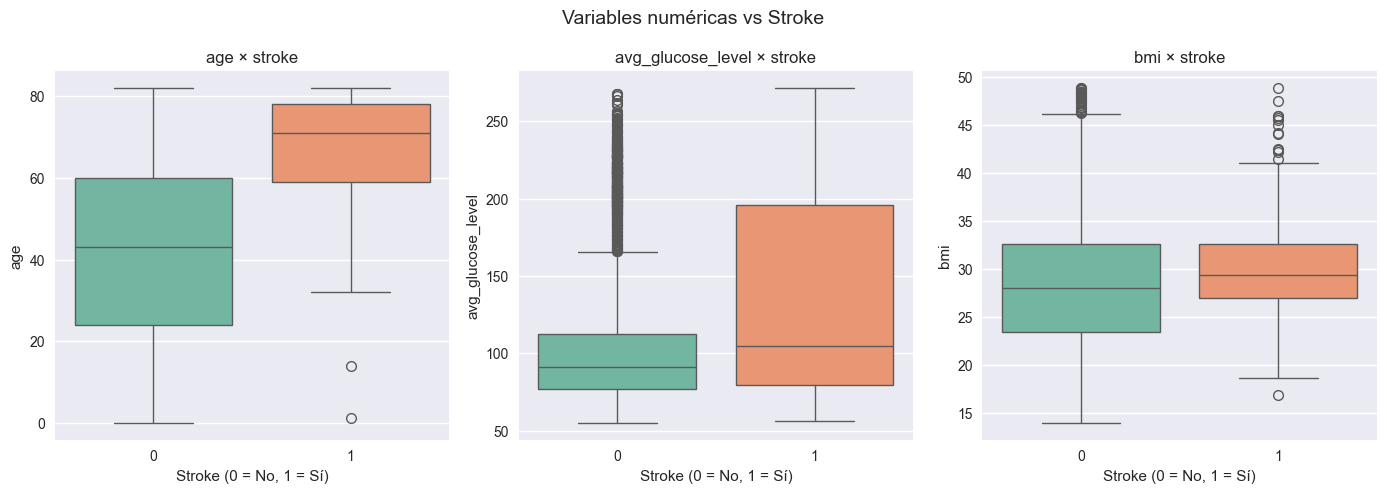

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Variables numéricas vs Stroke", fontsize=14)


for ax, num in zip(axes, df_num.columns.tolist()):
    sns.boxplot(data=df, x="stroke", y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × stroke")
    ax.set_xlabel("Stroke (0 = No, 1 = Sí)")

plt.tight_layout()
plt.show()

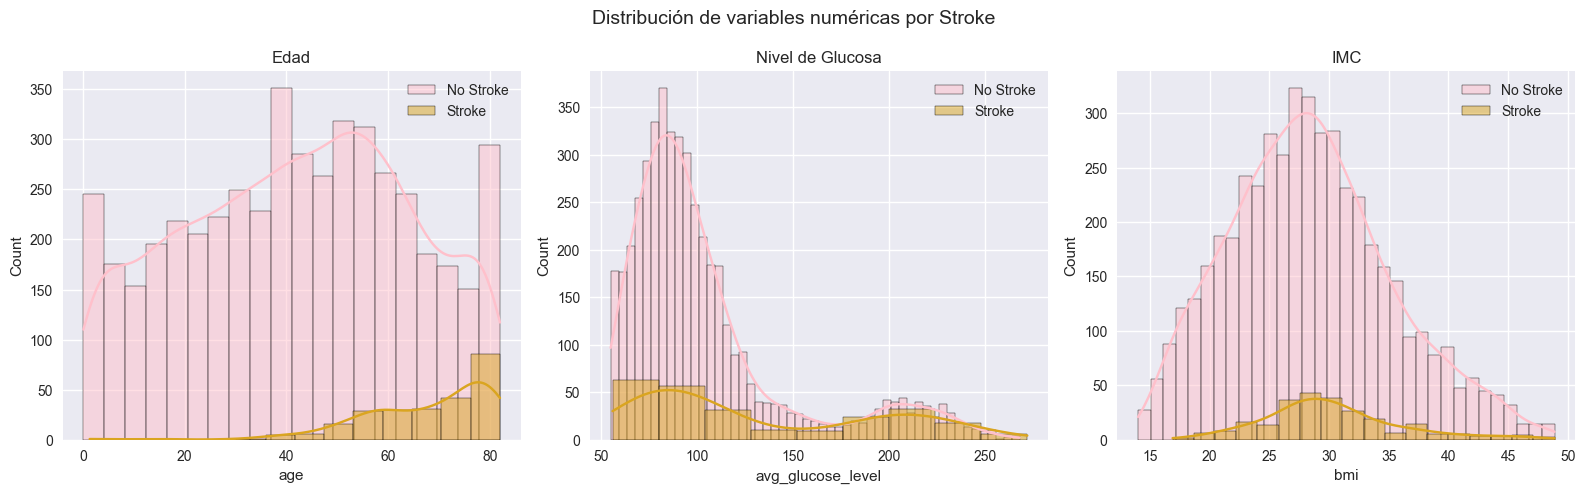

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución de variables numéricas por Stroke", fontsize=14)

vars_num = [("age", "Edad"), ("avg_glucose_level", "Nivel de Glucosa"), ("bmi", "IMC")]

for ax, (var, titulo) in zip(axes, vars_num):
    for stroke_val, color, label in [(0, "pink", "No Stroke"), (1, "goldenrod", "Stroke")]:
        subset = df[df["stroke"] == stroke_val][var]
        sns.histplot(subset, ax=ax, color=color, label=label, kde=True, alpha=0.5)
    ax.set_title(titulo)
    ax.set_xlabel(var)
    ax.legend()

plt.tight_layout()
plt.show()

Pruebas formales: Mann-Whitney U para diferencias de distribución entre clases

In [42]:
# Mann-Whitney U (no paramétrico) — robusto a la no normalidad observada en 3.1.
# H0: la distribución del predictor es la misma en stroke=0 y stroke=1.
from scipy.stats import mannwhitneyu
# stroke fue casteado a object en la sección 2; usar versión int aquí.
stroke_int = df["stroke"].astype(int)

resultados = []
for var in ["age", "avg_glucose_level", "bmi"]:
    g0 = df.loc[stroke_int == 0, var]
    g1 = df.loc[stroke_int == 1, var]
    stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
    resultados.append({"variable": var,
                       "median_no_stroke": g0.median(),
                       "median_stroke": g1.median(),
                       "U": stat, "p_value": p})

print(pd.DataFrame(resultados).to_string(index=False))


         variable  median_no_stroke  median_stroke        U      p_value
              age             43.00          71.00 978282.5 2.402842e-70
avg_glucose_level             91.45         105.04 716032.0 4.916558e-09
              bmi             28.00          29.45 683877.5 1.115734e-05


Las tres variables continuas muestran diferencias significativas entre los grupos stroke=0 y stroke=1. La diferencia es muy grande para age lo que significa que es el predictor más informativo. avg_glucose_level también separa bien los grupos (mediana 91 vs 105). bmi, aunque estadísticamente significativo, presenta una diferencia  pequeña (28 vs 29.5), lo que anticipa un efecto débil en el modelo.

Linealidad del logit (supuesto clave de la regresión logística)

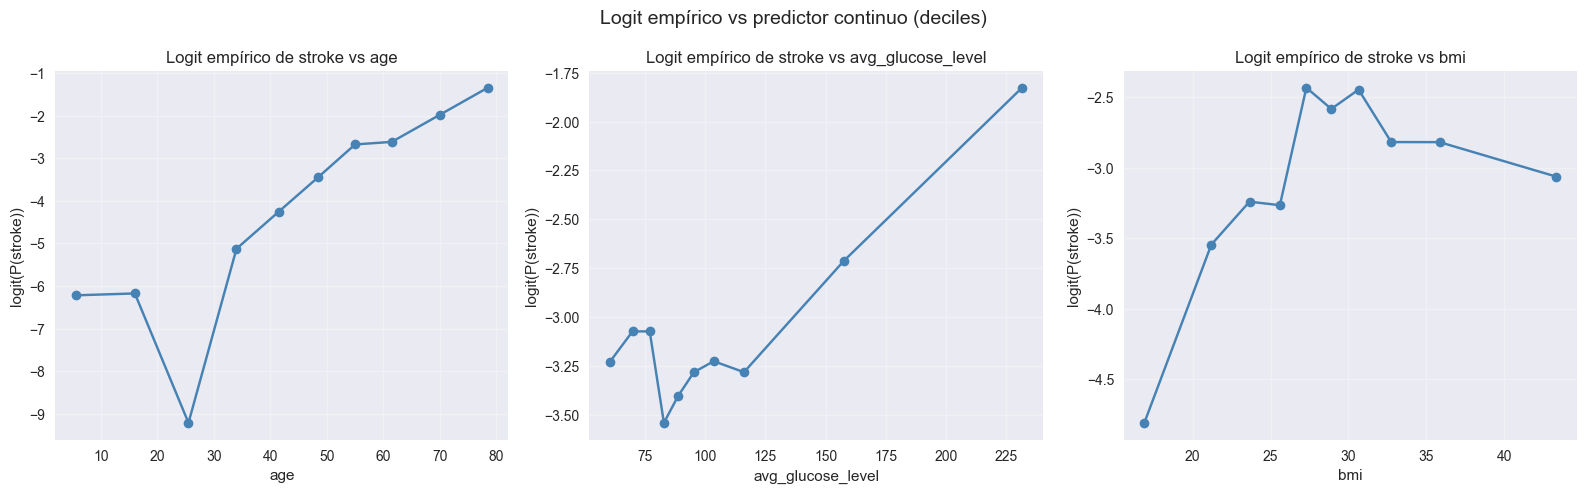

In [43]:
# Para cada variable continua: agrupar en deciles, calcular logit empírico
# (log(p/(1-p)) de stroke en cada bin) y graficar contra el punto medio del bin.
# Una línea recta justifica usar la variable cruda; curvatura indica que se
# requiere transformación, binning o spline.

# stroke está como object en este punto del notebook; trabajamos con copia int.
df_logit = df.assign(stroke=df["stroke"].astype(int))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Logit empírico vs predictor continuo (deciles)", fontsize=14)

for ax, var in zip(axes, ["age", "avg_glucose_level", "bmi"]):
    bins = pd.qcut(df_logit[var], q=10, duplicates="drop")
    grp = df_logit.groupby(bins, observed=True)["stroke"].agg(["mean", "count"])
    # logit con corrección para evitar log(0)
    grp["logit"] = np.log((grp["mean"] + 1e-4) / (1 - grp["mean"] + 1e-4))
    grp["x_mid"] = [interval.mid for interval in grp.index]
    ax.plot(grp["x_mid"], grp["logit"], marker="o", color="steelblue")
    ax.set_title(f"Logit empírico de stroke vs {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("logit(P(stroke))")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


age muestra un patrón aproximadamente lineal a partir de los 30 años. avg_glucose_level es plano hasta 120 y luego sube abruptamente lo cual implica que la linealidad del logit no se sostiene. Para solucionar esto un término categórico (glucosa alta vs normal) o un spline podria ser más apropiado. bmi muestra una forma no monótona (sube hasta 30, luego baja), señal de que el efecto de BMI no es lineal en el logit.

#### Variables categóricas

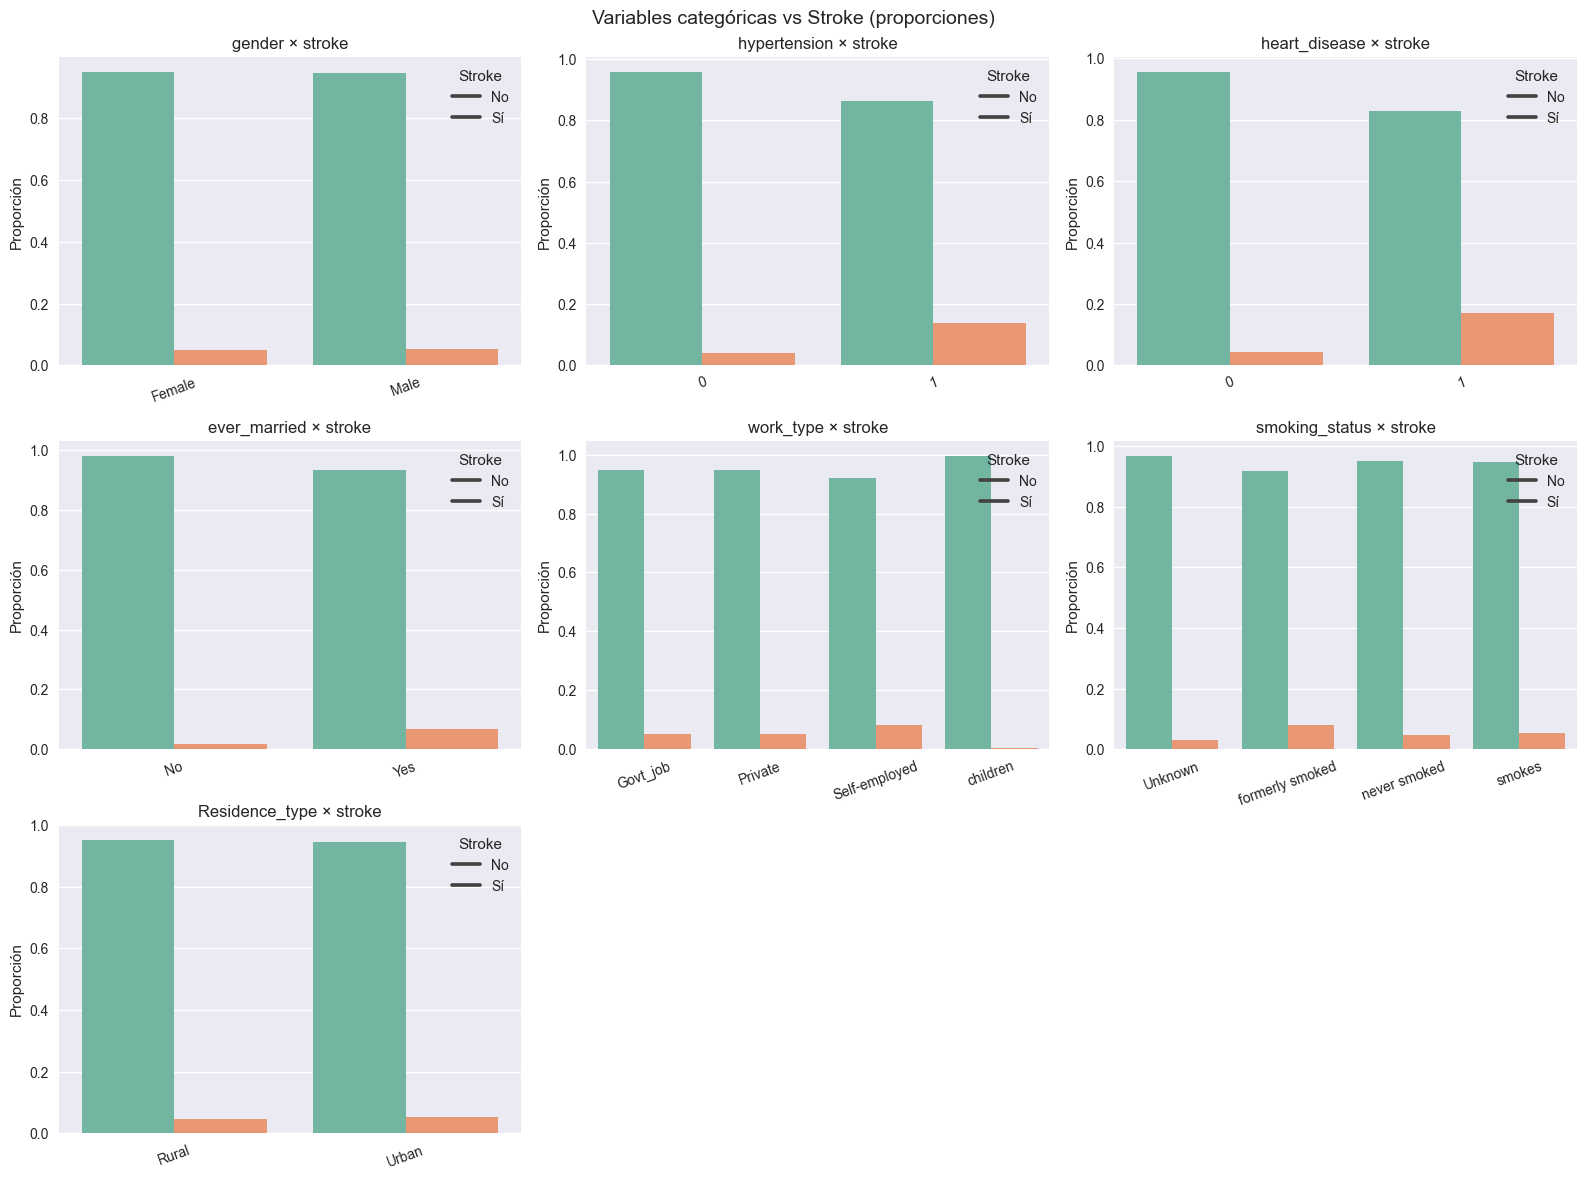

In [44]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Variables categóricas vs Stroke (proporciones)", fontsize=14)

categoricas = ["gender", "hypertension", "heart_disease", 
               "ever_married", "work_type", "smoking_status", "Residence_type"]

for ax, cat in zip(axes.flatten(), categoricas):
    prop = (df.groupby(cat)["stroke"]
              .value_counts(normalize=True)
              .rename("proporcion")
              .reset_index())
    sns.barplot(data=prop, x=cat, y="proporcion", hue="stroke", 
                ax=ax, palette="Set2")
    ax.set_title(f"{cat} × stroke")
    ax.set_xlabel("")
    ax.set_ylabel("Proporción")
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title="Stroke", labels=["No", "Sí"])

axes[2][2].set_visible(False)
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()  

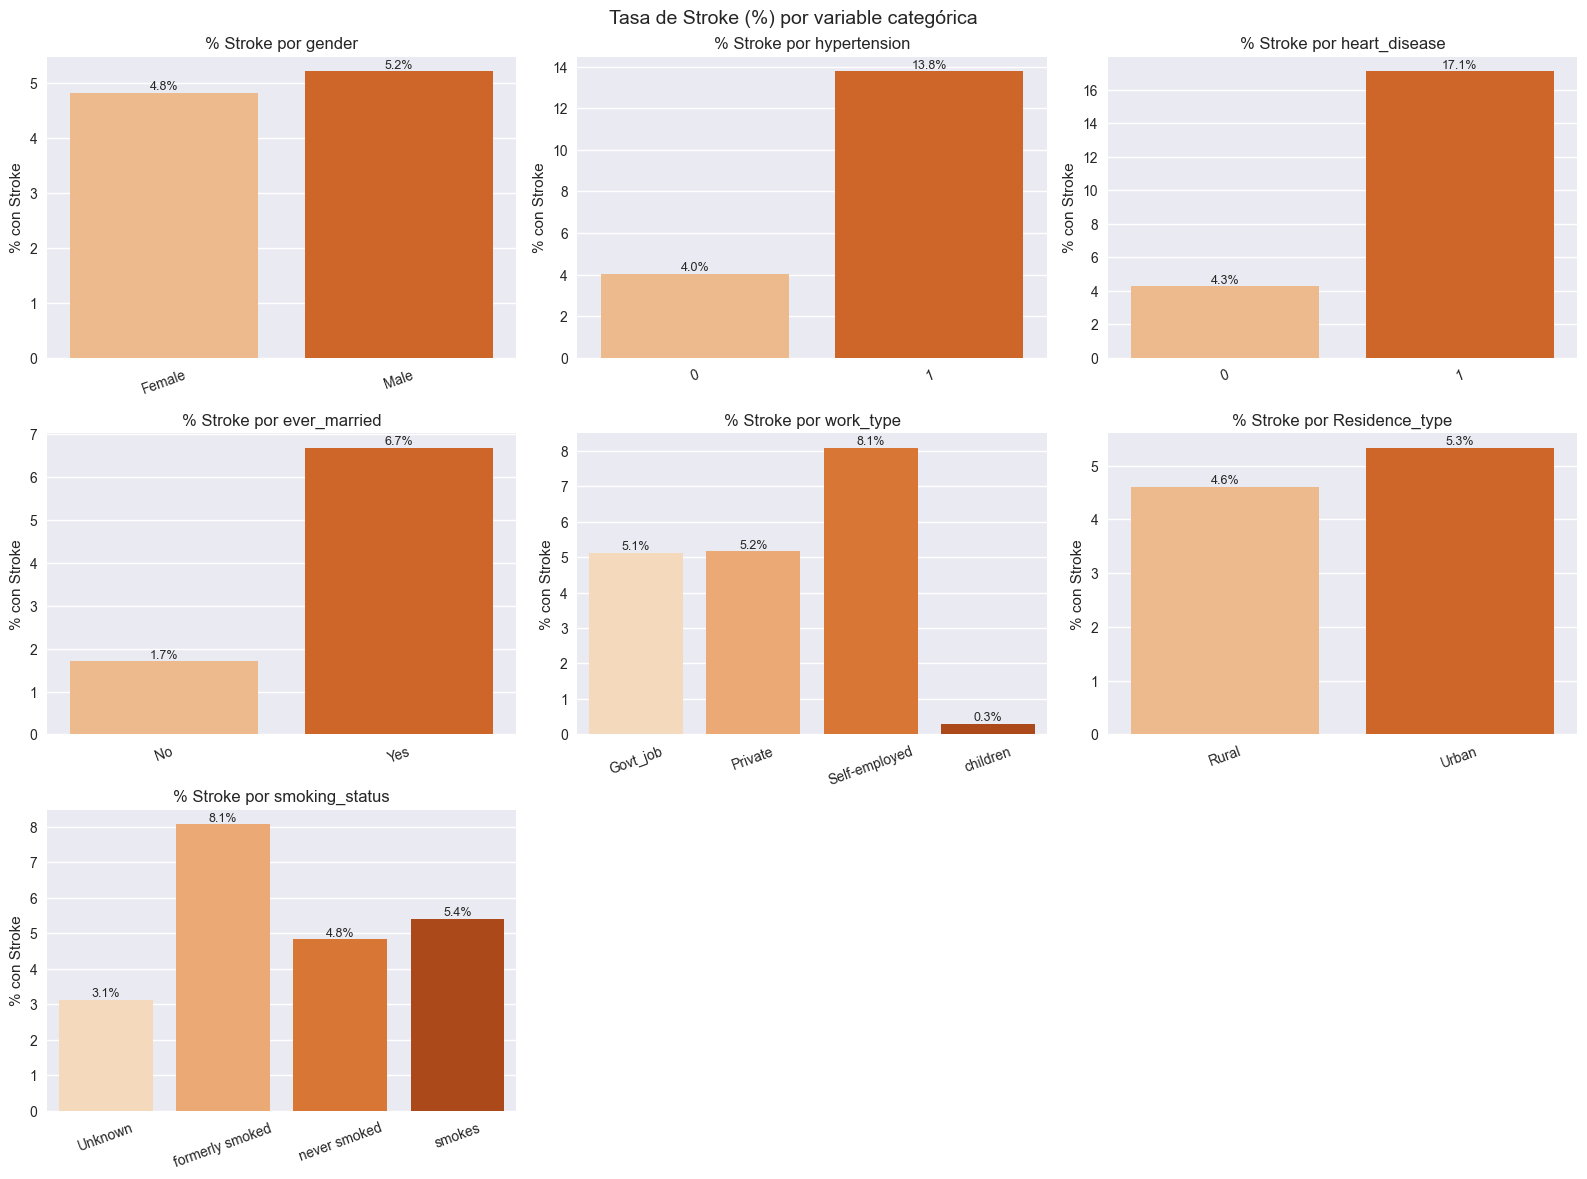

In [45]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Tasa de Stroke (%) por variable categórica", fontsize=14)
df['stroke'] = df['stroke'].astype(int)
for ax, cat in zip(axes.flatten(), df_cat.columns.tolist()):
    tasas = df.groupby(cat)["stroke"].mean().mul(100).round(2).reset_index()
    tasas.columns = [cat, "tasa"]
    sns.barplot(data=tasas, x=cat, y="tasa", ax=ax, palette="Oranges")
    ax.set_title(f"% Stroke por {cat}")
    ax.set_xlabel("")
    ax.set_ylabel("% con Stroke")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis='x', rotation=20)

axes[2][2].set_visible(False)
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

Pruebas formales: chi-cuadrado y conteos de eventos por celda (riesgo de separación)

In [46]:
# Chi-cuadrado de independencia entre cada predictor categórico y stroke.
# H0: el predictor es independiente de stroke.
from scipy.stats import chi2_contingency

categoricas = ["gender", "hypertension", "heart_disease",
               "ever_married", "work_type", "Residence_type", "smoking_status"]

resultados = []
for cat in categoricas:
    tabla = pd.crosstab(df[cat], df["stroke"])
    chi2, p, dof, _ = chi2_contingency(tabla)
    # V de Cramér como tamaño de efecto
    n = tabla.values.sum()
    cramer_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    resultados.append({"variable": cat, "chi2": chi2, "p_value": p,
                       "dof": dof, "cramer_V": cramer_v})

tabla_chi2 = pd.DataFrame(resultados).sort_values("p_value")
print(tabla_chi2.to_string(index=False))


      variable      chi2      p_value  dof  cramer_V
 heart_disease 87.566008 8.151357e-21    1  0.132590
  hypertension 84.697532 3.476842e-20    1  0.130400
  ever_married 57.481294 3.412090e-14    1  0.107425
     work_type 47.831772 2.312446e-10    3  0.097994
smoking_status 28.733513 2.547568e-06    3  0.075951
Residence_type  1.207675 2.717930e-01    1  0.015571
        gender  0.313520 5.755279e-01    1  0.007934


In [47]:
# Conteos de eventos por celda (chequeo de separación / cuasi-separación)
print("Conteos (no_stroke, stroke) por nivel de cada categórica:\n")
for cat in categoricas:
    tab = pd.crosstab(df[cat], df["stroke"])
    print(f"--- {cat} ---")
    print(tab)
    minimo = tab.min().min()
    if minimo == 0:
        print(" SEPARACIÓN: hay una celda vacía.")
    elif minimo < 10:
        print(f"Cuasi-separación: el menor conteo es {minimo}.")
    print()


Conteos (no_stroke, stroke) por nivel de cada categórica:

--- gender ---
stroke     0    1
gender           
Female  2767  140
Male    1966  108

--- hypertension ---
stroke           0    1
hypertension           
0             4320  182
1              413   66

--- heart_disease ---
stroke            0    1
heart_disease           
0              4505  201
1               228   47

--- ever_married ---
stroke           0    1
ever_married           
No            1672   29
Yes           3061  219

--- work_type ---
stroke            0    1
work_type               
Govt_job        611   33
Private        2712  148
Self-employed   739   65
children        671    2
Cuasi-separación: el menor conteo es 2.

--- Residence_type ---
stroke             0    1
Residence_type           
Rural           2336  113
Urban           2397  135

--- smoking_status ---
stroke              0   1
smoking_status           
Unknown          1453  47
formerly smoked   797  70
never smoked     1749  89
smok

La asociación es significativa para age, hypertension, heart_disease, ever_married, work_type y smoking_status. Para gender y Residence_type no se rechaza la independencia con stroke. La categoría work_type=children solo tiene 2 eventos (cuasi-separación): su coeficiente será inestable y debe interpretarse con cautela.

### 3.3) Conclusiones del EDA y especificación del modelo

**Predictores que entran al modelo:**
- age: efecto fuerte y aproximadamente lineal en el logit (a partir de 30 años).
- avg_glucose_level: efecto significativo pero*no lineal en el logit (plano hasta 120, salto a partir de ahí). Se conserva en forma cruda y se documenta el supuesto incumplido.
- bmi: relación no monótona en el logit; aporta señal débil (Mann-Whitney p ≈ 1e-5) y se conserva con la misma advertencia.
- hypertension, heart_disease: efectos claros (chi² altamente significativos).
- work_type, smoking_status: significativos en chi² aunque con tamaños de efecto modestos (V de Cramér < 0.1).
- gender: no significativo (chi² p ≈ 0.58); se incluye sólo como variable de control sustantiva.

**Predictores excluidos:**
- Residence_type: chi² p ≈ 0.27, sin señal frente a stroke.
- ever_married: capta esencialmente el efecto de age; se omite por parsimonia.

**Sin transformaciones logarítmicas** (descartadas en 3.1).

**Una sola interacción** se evalúa por motivación clínica: age × hypertension.


## 4) Partición train/test

División estratificada 80/20 antes de cualquier remuestreo o codificación que dependa de los datos. El set de prueba se mantiene intacto.

In [48]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} obs, prevalencia stroke = {y_train.mean()*100:.2f}%")
print(f"Test : {X_test.shape[0]} obs, prevalencia stroke = {y_test.mean()*100:.2f}%")


Train: 3984 obs, prevalencia stroke = 4.97%
Test : 997 obs, prevalencia stroke = 5.02%


In [49]:
# Fijar categorías de referencia y codificar con drop_first=True
X_train["smoking_status"] = pd.Categorical(
    X_train["smoking_status"],
    categories=["never smoked", "formerly smoked", "smokes", "Unknown"]
)
X_test["smoking_status"] = pd.Categorical(
    X_test["smoking_status"],
    categories=["never smoked", "formerly smoked", "smokes", "Unknown"]
)
X_train["work_type"] = pd.Categorical(
    X_train["work_type"],
    categories=["Private", "Govt_job", "Self-employed", "children"]
)
X_test["work_type"] = pd.Categorical(
    X_test["work_type"],
    categories=["Private", "Govt_job", "Self-employed", "children"]
)

X_train_enc = pd.get_dummies(X_train, drop_first=True).astype(float)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True).astype(float)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

def clean(cols):
    return cols.str.replace(" ", "_").str.replace("-", "_")
X_train_enc.columns = clean(X_train_enc.columns)
X_test_enc.columns  = clean(X_test_enc.columns)

# Empaquetar para statsmodels
df_train_unbal = X_train_enc.copy()
df_train_unbal["stroke"] = y_train.values

df_test = X_test_enc.copy()
df_test["stroke"] = y_test.values

print("Columnas codificadas:", list(X_train_enc.columns))


Columnas codificadas: ['age', 'avg_glucose_level', 'bmi', 'gender_Male', 'hypertension_1', 'heart_disease_1', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Self_employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly_smoked', 'smoking_status_smokes', 'smoking_status_Unknown']


## 5) Decisión sobre balanceo de clases

Antes de construir los modelos finales se realiza un experimento para decidir si vale la pena aplicar balanceo (SMOTE-NC) sobre el conjunto de entrenamiento. Se ajusta el mismo modelo sobre el train sin balancear y sobre el train balanceado con SMOTE-NC, y se evalúan ambos sobre el mismo conjunto de prueba


### 5.1) Modelo sin balanceo

In [50]:
# Métricas de evaluación reutilizables para los tres modelos.
from sklearn.metrics import average_precision_score

def evaluar_modelo(modelo, df_tr, df_te, etiqueta):
    """Evalúa un modelo de statsmodels (con .predict) sobre el test.
    Devuelve métricas threshold-free + threshold tuned por F1 en train."""
    p_tr = modelo.predict(df_tr)
    p_te = modelo.predict(df_te)
    y_tr = df_tr["stroke"].astype(int).values
    y_te = df_te["stroke"].astype(int).values

    # Threshold óptimo (F1) en train, evitando el sesgo del 0.5
    thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_tr, (p_tr >= t).astype(int), zero_division=0) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]

    return {
        "etiqueta": etiqueta,
        "p_test": p_te,
        "y_test": y_te,
        "auc_roc": roc_auc_score(y_te, p_te),
        "auc_pr":  average_precision_score(y_te, p_te),
        "brier":   brier_score_loss(y_te, p_te),
        "log_loss": log_loss(y_te, p_te),
        "best_threshold": best_t,
        "y_pred_05":    (p_te >= 0.5).astype(int),
        "y_pred_tuned": (p_te >= best_t).astype(int),
    }


In [51]:
# Se incluyen las variables que mostraron relación con stroke o con algun otro predictor en el análisis (Principio de Jerarquía).
# Se incluyeron las interacciones que mostraron señal en el análisis bivariado

formula = """stroke ~ age + avg_glucose_level + bmi + hypertension_1 +
             work_type_Govt_job + work_type_Self_employed + work_type_children +
             smoking_status_formerly_smoked + smoking_status_smokes + 
             smoking_status_Unknown + heart_disease_1 +
             age:hypertension_1 + age:bmi + age:heart_disease_1 +
             avg_glucose_level:hypertension_1 + avg_glucose_level:heart_disease_1 +
             hypertension_1:heart_disease_1 +
             heart_disease_1:smoking_status_formerly_smoked +
             heart_disease_1:smoking_status_smokes +
             heart_disease_1:smoking_status_Unknown"""

modelo_eda_unbal = logit(formula, data=df_train_unbal).fit(disp=False)
print(modelo_eda_unbal.summary())


                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 3984
Model:                          Logit   Df Residuals:                     3963
Method:                           MLE   Df Model:                           20
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2125
Time:                        00:24:19   Log-Likelihood:                -620.01
converged:                       True   LL-Null:                       -787.35
Covariance Type:            nonrobust   LLR p-value:                 6.363e-59
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                        -11.0363      1.864     -5.922      0.000     -14.689      -7.384
age                    

In [52]:
r1 = evaluar_modelo(modelo_eda_unbal, df_train_unbal, df_test, "Modelo EDA (sin balanceo)")

print(f"ROC AUC : {r1['auc_roc']:.4f}")
print(f"PR AUC  : {r1['auc_pr']:.4f}")
print(f"Brier   : {r1['brier']:.4f}")
print(f"Log-loss: {r1['log_loss']:.4f}")
print(f"Threshold óptimo (F1): {r1['best_threshold']:.3f}\n")

print("--- Classification report @ threshold=0.5 ---")
print(classification_report(r1["y_test"], r1["y_pred_05"], digits=3, zero_division=0))
print(f"--- Classification report @ threshold={r1['best_threshold']:.3f} (tuned) ---")
print(classification_report(r1["y_test"], r1["y_pred_tuned"], digits=3, zero_division=0))


ROC AUC : 0.8449
PR AUC  : 0.2085
Brier   : 0.0435
Log-loss: 0.1588
Threshold óptimo (F1): 0.150

--- Classification report @ threshold=0.5 ---
              precision    recall  f1-score   support

           0      0.951     0.999     0.974       947
           1      0.500     0.020     0.038        50

    accuracy                          0.950       997
   macro avg      0.725     0.509     0.506       997
weighted avg      0.928     0.950     0.927       997

--- Classification report @ threshold=0.150 (tuned) ---
              precision    recall  f1-score   support

           0      0.966     0.919     0.942       947
           1      0.198     0.380     0.260        50

    accuracy                          0.892       997
   macro avg      0.582     0.649     0.601       997
weighted avg      0.927     0.892     0.907       997



### 5.2) Modelo con SMOTE-NC

SMOTE-NC aplicado sólo al train (el test conserva prevalencia natural). Se usa la variante NC porque las dummies one-hot no admiten interpolación: SMOTE clásico generaría valores fraccionarios sin sentido (ej. gender_Male = 0.42).


In [53]:
from imblearn.over_sampling import SMOTENC

num_cols = ["age", "avg_glucose_level", "bmi"]
cat_idx  = [i for i, c in enumerate(X_train_enc.columns) if c not in num_cols]

smote_nc = SMOTENC(categorical_features=cat_idx,
                   sampling_strategy=0.25, random_state=42)
X_train_bal, y_train_bal = smote_nc.fit_resample(X_train_enc, y_train)

df_train_bal = X_train_bal.copy()
df_train_bal["stroke"] = y_train_bal.values

print("Train antes :", X_train_enc.shape, f"| prevalencia = {y_train.mean()*100:.2f}%")
print("Train después:", df_train_bal.shape, f"| prevalencia = {y_train_bal.mean()*100:.2f}%")


Train antes : (3984, 14) | prevalencia = 4.97%
Train después: (4732, 15) | prevalencia = 19.99%


In [54]:
modelo_eda_bal = logit(formula, data=df_train_bal).fit(disp=False)
print(modelo_eda_bal.summary())


                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4732
Model:                          Logit   Df Residuals:                     4711
Method:                           MLE   Df Model:                           20
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.3340
Time:                        00:24:20   Log-Likelihood:                -1576.7
converged:                       True   LL-Null:                       -2367.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                         -6.8283      1.049     -6.512      0.000      -8.883      -4.773
age                    

In [55]:
r2 = evaluar_modelo(modelo_eda_bal, df_train_bal, df_test, "Modelo 2 (SMOTE-NC)")

print(f"ROC AUC : {r2['auc_roc']:.4f}")
print(f"PR AUC  : {r2['auc_pr']:.4f}")
print(f"Brier   : {r2['brier']:.4f}")
print(f"Log-loss: {r2['log_loss']:.4f}")
print(f"Threshold óptimo (F1): {r2['best_threshold']:.3f}\n")

print("--- Classification report @ threshold=0.5 ---")
print(classification_report(r2["y_test"], r2["y_pred_05"], digits=3, zero_division=0))
print(f"--- Classification report @ threshold={r2['best_threshold']:.3f} (tuned) ---")
print(classification_report(r2["y_test"], r2["y_pred_tuned"], digits=3, zero_division=0))


ROC AUC : 0.7820
PR AUC  : 0.1867
Brier   : 0.0675
Log-loss: 0.2341
Threshold óptimo (F1): 0.330

--- Classification report @ threshold=0.5 ---
              precision    recall  f1-score   support

           0      0.967     0.947     0.957       947
           1      0.275     0.380     0.319        50

    accuracy                          0.919       997
   macro avg      0.621     0.664     0.638       997
weighted avg      0.932     0.919     0.925       997

--- Classification report @ threshold=0.330 (tuned) ---
              precision    recall  f1-score   support

           0      0.973     0.875     0.922       947
           1      0.186     0.540     0.277        50

    accuracy                          0.859       997
   macro avg      0.580     0.708     0.599       997
weighted avg      0.934     0.859     0.889       997



### 5.3) Comparación y decisión

¿Vale la pena el balanceo? Se contrasta sobre el **mismo test** intacto.


In [56]:
# Coeficientes lado a lado
coefs = pd.DataFrame({
    "M1 (sin balanceo)": modelo_eda_unbal.params,
    "M2 (SMOTE-NC)":     modelo_eda_bal.params,
})
coefs["cambio (M2 - M1)"] = coefs["M2 (SMOTE-NC)"] - coefs["M1 (sin balanceo)"]
print(coefs.round(3))


                                                M1 (sin balanceo)  \
Intercept                                                 -11.036   
age                                                         0.117   
avg_glucose_level                                           0.005   
bmi                                                         0.100   
hypertension_1                                              1.295   
work_type_Govt_job                                         -0.288   
work_type_Self_employed                                    -0.287   
work_type_children                                          1.947   
smoking_status_formerly_smoked                              0.282   
smoking_status_smokes                                       0.129   
smoking_status_Unknown                                      0.217   
heart_disease_1                                             1.251   
age:hypertension_1                                         -0.007   
age:bmi                           

In [57]:
# Tabla de métricas
metricas = pd.DataFrame({
    "Modelo 1 (sin balanceo)": [r1["auc_roc"], r1["auc_pr"], r1["brier"],
                                r1["log_loss"], r1["best_threshold"]],
    "Modelo 2 (SMOTE-NC)":     [r2["auc_roc"], r2["auc_pr"], r2["brier"],
                                r2["log_loss"], r2["best_threshold"]],
}, index=["ROC AUC", "PR AUC", "Brier", "Log-loss", "Threshold óptimo"])
print(metricas.round(4))


                  Modelo 1 (sin balanceo)  Modelo 2 (SMOTE-NC)
ROC AUC                            0.8449               0.7820
PR AUC                             0.2085               0.1867
Brier                              0.0435               0.0675
Log-loss                           0.1588               0.2341
Threshold óptimo                   0.1500               0.3300


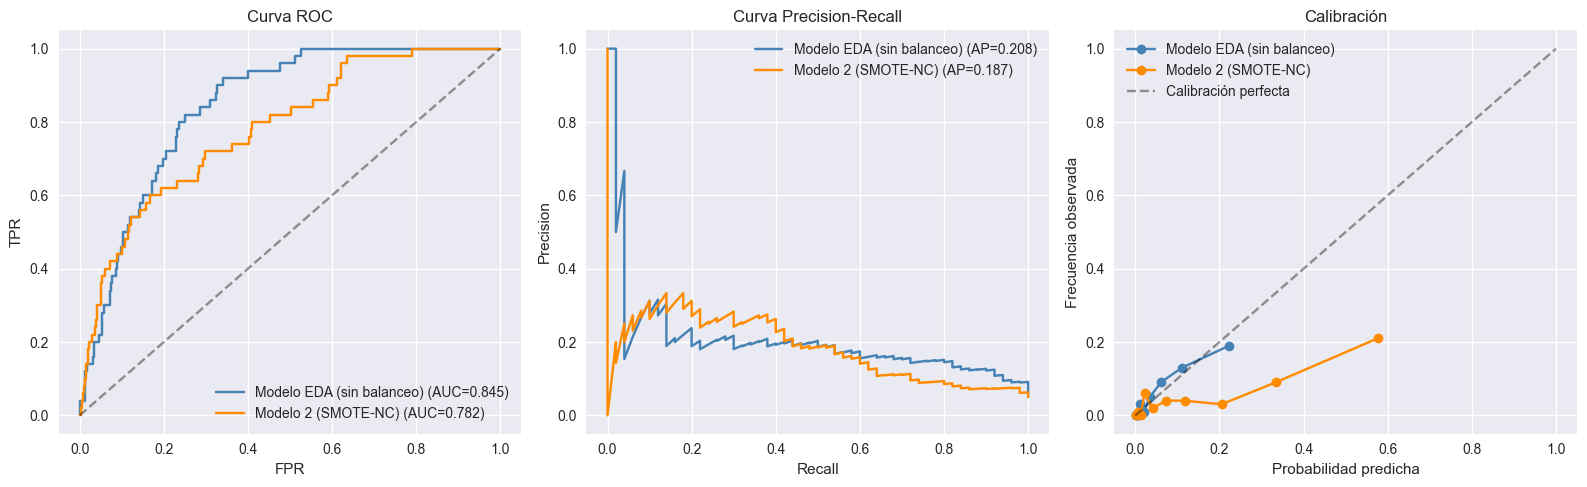

In [58]:
# Curvas ROC, PR y calibración superpuestas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
for r, color in [(r1, "steelblue"), (r2, "darkorange")]:
    fpr, tpr, _ = roc_curve(r["y_test"], r["p_test"])
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{r['etiqueta']} (AUC={r['auc_roc']:.3f})")
axes[0].plot([0,1],[0,1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC"); axes[0].legend()

# Precision-Recall
for r, color in [(r1, "steelblue"), (r2, "darkorange")]:
    prec, rec, _ = precision_recall_curve(r["y_test"], r["p_test"])
    axes[1].plot(rec, prec, color=color,
                 label=f"{r['etiqueta']} (AP={r['auc_pr']:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall"); axes[1].legend()

# Calibración (por cuantiles para que cada bin tenga tamaño similar)
for r, color in [(r1, "steelblue"), (r2, "darkorange")]:
    prob_true, prob_pred = calibration_curve(r["y_test"], r["p_test"],
                                              n_bins=10, strategy="quantile")
    axes[2].plot(prob_pred, prob_true, "o-", color=color, label=r["etiqueta"])
axes[2].plot([0,1],[0,1], "k--", alpha=0.4, label="Calibración perfecta")
axes[2].set_xlabel("Probabilidad predicha"); axes[2].set_ylabel("Frecuencia observada")
axes[2].set_title("Calibración"); axes[2].legend()

plt.tight_layout()
plt.show()


Conclusiones de ensayo balanceo

- AUC empeora con SMOTE. ROC AUC pasa de 0.845 (M1) a 0.782 (M2) y PR AUC de 0.208 a 0.187.
- Calibración se rompe. M2 sobre-estima sistemáticamente la probabilidad de stroke porque entrenó sobre la prevalencia inflada al 20%. Brier y Log-loss reflejan esto (0.068 vs 0.044 en Brier; 0.234 vs 0.159 en Log-loss).
- Coeficientes: las pendientes en variables clave (age, avg_glucose_level, bmi) son similares entre M1 y M2. La diferencia mayor está en el intercepto (más negativo en M1, reflejando la prevalencia real) y en los efectos categóricos, que se reorganizan para acomodar la prevalencia inflada.
- Threshold ajustado: M1 obtiene su mejor F1 en threshold=0.15; M2 en threshold=0.33. La aparente ventaja de recall que reporte M2 a su threshold viene a costa de calibración perdida.

Por esto concluimos que SMOTE-NC no compensa. Entonces, para inferencia poblacional y para predicción no utilizarlo es mejor.


## 6) Construcción de modelos

### 6.1) Estandarización de variables continuas

Se estandarizan únicamente las continuas age, avg_glucose_level y bmi usando media y desviación del train. La misma transformación se aplica al test.

In [59]:
from sklearn.preprocessing import StandardScaler

num_cols = ["age", "avg_glucose_level", "bmi"]
scaler = StandardScaler()

df_train_unbal_std = df_train_unbal.copy()
df_train_unbal_std[num_cols] = scaler.fit_transform(df_train_unbal[num_cols])

df_test_std = df_test.copy()
df_test_std[num_cols] = scaler.transform(df_test[num_cols])


### 6.2) Modelo resultante del análisis de datos

In [60]:
# El modelo se ajusta sobre el conjunto de entrenamiento no balanceado (df_train_unbal_std) y estandarizado.
# Se incluyen las variables que mostraron relación con stroke o con algun otro predictor en el análisis (Principio de Jerarquía).
# Se incluyeron las interacciones que mostraron señal en el análisis bivariado

formula = """stroke ~ age + avg_glucose_level + bmi + hypertension_1 +
             work_type_Govt_job + work_type_Self_employed + work_type_children +
             smoking_status_formerly_smoked + smoking_status_smokes + 
             smoking_status_Unknown + heart_disease_1 +
             age:hypertension_1 + age:bmi + age:heart_disease_1 +
             avg_glucose_level:hypertension_1 + avg_glucose_level:heart_disease_1 +
             hypertension_1:heart_disease_1 +
             heart_disease_1:smoking_status_formerly_smoked +
             heart_disease_1:smoking_status_smokes +
             heart_disease_1:smoking_status_Unknown"""

modelo_eda = logit(formula, data=df_train_unbal_std).fit(disp=False)
print(modelo_eda.summary())


                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 3984
Model:                          Logit   Df Residuals:                     3963
Method:                           MLE   Df Model:                           20
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2125
Time:                        00:24:21   Log-Likelihood:                -620.01
converged:                       True   LL-Null:                       -787.35
Covariance Type:            nonrobust   LLR p-value:                 6.363e-59
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                         -4.3325      0.236    -18.367      0.000      -4.795      -3.870
age                    

### 6.3) Modelo EDA reducido por jerarquía y parsimonia

In [61]:
# El modelo se ajusta sobre el conjunto de entrenamiento no balanceado (df_train_unbal_std) y estandarizado.
# Se incluyen las variables que mostraron relación con stroke o con algun otro predictor en el análisis y que resultaron significativas en el modelo anterior
# Se incluyeron las interacciones que mostraron señal en el análisis bivariado y que resultaron significativas en el modelo anterior.
# Se respeta la regla de jerarquía: si se incluye una interacción, se mantienen los términos principales aunque no sean significativos.

formula_reducido = """stroke ~ age + avg_glucose_level + bmi + hypertension_1 +
                      work_type_Govt_job + work_type_Self_employed + work_type_children +
                      smoking_status_formerly_smoked + smoking_status_smokes + 
                      smoking_status_Unknown + heart_disease_1 +
                      age:heart_disease_1 +
                      avg_glucose_level:heart_disease_1 +
                      heart_disease_1:smoking_status_formerly_smoked +
                      heart_disease_1:smoking_status_smokes +
                      heart_disease_1:smoking_status_Unknown"""

modelo_eda_reducido = logit(formula_reducido, data=df_train_unbal_std).fit(disp=False)
print(modelo_eda_reducido.summary())


                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 3984
Model:                          Logit   Df Residuals:                     3967
Method:                           MLE   Df Model:                           16
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2105
Time:                        00:24:21   Log-Likelihood:                -621.62
converged:                       True   LL-Null:                       -787.35
Covariance Type:            nonrobust   LLR p-value:                 7.519e-61
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                         -4.2413      0.221    -19.231      0.000      -4.674      -3.809
age                    

### 6.4) Modelo sacado de literatura (OMS)

In [62]:
# El modelo se ajusta sobre el conjunto de entrenamiento no balanceado (df_train_unbal_std) y estandarizado.
# Se incluyen las variables que pueden son factores de riesgo mencionados por la OMS
# Se incluye la interacción entre edad y fumar, ya que la OMS menciona que dos de cada 5 muertes por ACV en menores de 65 estan relacionadas con el tabaquismo

formula_oms = """stroke ~ age + avg_glucose_level + bmi + hypertension_1 +
                 smoking_status_formerly_smoked + smoking_status_smokes +
                 smoking_status_Unknown + heart_disease_1 +
                 age:smoking_status_formerly_smoked +
                 age:smoking_status_smokes +
                 age:smoking_status_Unknown"""

modelo_oms = logit(formula_oms, data=df_train_unbal_std).fit(disp=False)
print(modelo_oms.summary())


                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 3984
Model:                          Logit   Df Residuals:                     3972
Method:                           MLE   Df Model:                           11
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2044
Time:                        00:24:22   Log-Likelihood:                -626.40
converged:                       True   LL-Null:                       -787.35
Covariance Type:            nonrobust   LLR p-value:                 2.111e-62
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -4.6434      0.317    -14.631      0.000      -5.265      -4.021
age                                    1.8925      0.250   

### 6.5) Modelo LASSO

In [63]:
# El modelo se ajusta sobre el conjunto de entrenamiento no balanceado (df_train_unbal_std) y estandarizado.
# Se incluyen todas las variables
# Se incluyen todas las interacciones de segundo orden
# Penalización Lasso (L1) para selección automática de variables e interacciones, con validación cruzada

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from patsy import dmatrices

formula_lasso_full = """stroke ~ (age + avg_glucose_level + bmi + hypertension_1 +
                        gender_Male + ever_married_Yes + Residence_type_Urban +
                        work_type_Govt_job + work_type_Self_employed + work_type_children +
                        smoking_status_formerly_smoked + smoking_status_smokes + 
                        smoking_status_Unknown + heart_disease_1)**2"""

y_lasso, X_lasso = dmatrices(formula_lasso_full, data=df_train_unbal_std, return_type='dataframe')
y_lasso = y_lasso.values.ravel()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo_lasso = LogisticRegressionCV(
    Cs=np.logspace(-4, 1, 50),  # grilla de 0.0001 a 10
    cv=cv, penalty='l1', solver='saga',
    scoring='neg_log_loss', max_iter=10000, random_state=42
)
modelo_lasso.fit(X_lasso, y_lasso)

coef_lasso = pd.Series(modelo_lasso.coef_[0], index=X_lasso.columns)
retenidas = coef_lasso[abs(coef_lasso) > 1e-4]
eliminadas = coef_lasso[abs(coef_lasso) <= 1e-4]

print(f"C óptimo: {modelo_lasso.C_[0]:.6f}")
print(f"Variables totales: {len(coef_lasso)}")
print(f"Variables retenidas: {len(retenidas)}")
print(f"Variables eliminadas: {len(eliminadas)}")
print("\nCoeficientes retenidos:")
print(retenidas.round(4))

C óptimo: 0.115140
Variables totales: 106
Variables retenidas: 13
Variables eliminadas: 93

Coeficientes retenidos:
age                                          1.4202
hypertension_1                               0.1337
age:avg_glucose_level                        0.0030
age:hypertension_1                           0.1251
avg_glucose_level:bmi                        0.0910
avg_glucose_level:gender_Male                0.0842
avg_glucose_level:ever_married_Yes           0.1226
avg_glucose_level:Residence_type_Urban       0.0766
avg_glucose_level:work_type_Self_employed   -0.0759
avg_glucose_level:smoking_status_smokes      0.0085
avg_glucose_level:heart_disease_1            0.0853
bmi:gender_Male                              0.0046
bmi:Residence_type_Urban                     0.0251
dtype: float64


In [64]:
pd.set_option('display.max_rows', 100)
print(coef_lasso[abs(coef_lasso) > 1e-4].round(4).to_string())

age                                          1.4202
hypertension_1                               0.1337
age:avg_glucose_level                        0.0030
age:hypertension_1                           0.1251
avg_glucose_level:bmi                        0.0910
avg_glucose_level:gender_Male                0.0842
avg_glucose_level:ever_married_Yes           0.1226
avg_glucose_level:Residence_type_Urban       0.0766
avg_glucose_level:work_type_Self_employed   -0.0759
avg_glucose_level:smoking_status_smokes      0.0085
avg_glucose_level:heart_disease_1            0.0853
bmi:gender_Male                              0.0046
bmi:Residence_type_Urban                     0.0251


In [65]:
formula_lasso_final = """stroke ~ age + avg_glucose_level + bmi + hypertension_1 +
                         gender_Male + ever_married_Yes + Residence_type_Urban +
                         work_type_Govt_job + work_type_Self_employed + work_type_children +
                         smoking_status_formerly_smoked + smoking_status_smokes +
                         smoking_status_Unknown + heart_disease_1 +
                         age:avg_glucose_level + age:bmi + age:gender_Male +
                         age:ever_married_Yes + age:Residence_type_Urban +
                         age:work_type_Self_employed + age:work_type_children +
                         age:smoking_status_formerly_smoked + age:smoking_status_smokes +
                         age:smoking_status_Unknown + age:heart_disease_1 +
                         avg_glucose_level:bmi + avg_glucose_level:hypertension_1 +
                         avg_glucose_level:gender_Male + avg_glucose_level:ever_married_Yes +
                         avg_glucose_level:Residence_type_Urban +
                         avg_glucose_level:work_type_Govt_job +
                         avg_glucose_level:work_type_Self_employed +
                         avg_glucose_level:smoking_status_formerly_smoked +
                         avg_glucose_level:smoking_status_smokes +
                         avg_glucose_level:smoking_status_Unknown +
                         avg_glucose_level:heart_disease_1 +
                         bmi:hypertension_1 + bmi:gender_Male + bmi:ever_married_Yes +
                         bmi:Residence_type_Urban + bmi:work_type_Govt_job +
                         bmi:work_type_Self_employed + bmi:heart_disease_1 +
                         hypertension_1:gender_Male + hypertension_1:ever_married_Yes +
                         hypertension_1:Residence_type_Urban +
                         hypertension_1:work_type_Govt_job +
                         hypertension_1:work_type_Self_employed +
                         hypertension_1:smoking_status_formerly_smoked +
                         hypertension_1:smoking_status_Unknown +
                         gender_Male:Residence_type_Urban +
                         gender_Male:work_type_Govt_job + gender_Male:work_type_Self_employed +
                         gender_Male:smoking_status_formerly_smoked +
                         gender_Male:smoking_status_smokes +
                         gender_Male:smoking_status_Unknown + gender_Male:heart_disease_1 +
                         ever_married_Yes:Residence_type_Urban +
                         ever_married_Yes:work_type_Govt_job +
                         ever_married_Yes:work_type_Self_employed +
                         ever_married_Yes:smoking_status_Unknown +
                         ever_married_Yes:heart_disease_1 +
                         Residence_type_Urban:work_type_Self_employed +
                         Residence_type_Urban:smoking_status_formerly_smoked +
                         Residence_type_Urban:smoking_status_smokes +
                         work_type_Govt_job:smoking_status_Unknown +
                         work_type_Self_employed:smoking_status_formerly_smoked +
                         work_type_Self_employed:smoking_status_smokes +
                         work_type_Self_employed:smoking_status_Unknown +
                         smoking_status_formerly_smoked:heart_disease_1 +
                         smoking_status_smokes:heart_disease_1"""

modelo_lasso_final = logit(formula_lasso_final, data=df_train_unbal_std).fit(disp=False)
print(modelo_lasso_final.summary())

                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 3984
Model:                          Logit   Df Residuals:                     3912
Method:                           MLE   Df Model:                           71
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2507
Time:                        00:27:54   Log-Likelihood:                -589.92
converged:                       True   LL-Null:                       -787.35
Covariance Type:            nonrobust   LLR p-value:                 1.961e-46
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                 -6.0510      0.842     -7.182      0.000      -7.702      -4.400

## 7) Comparación de modelos

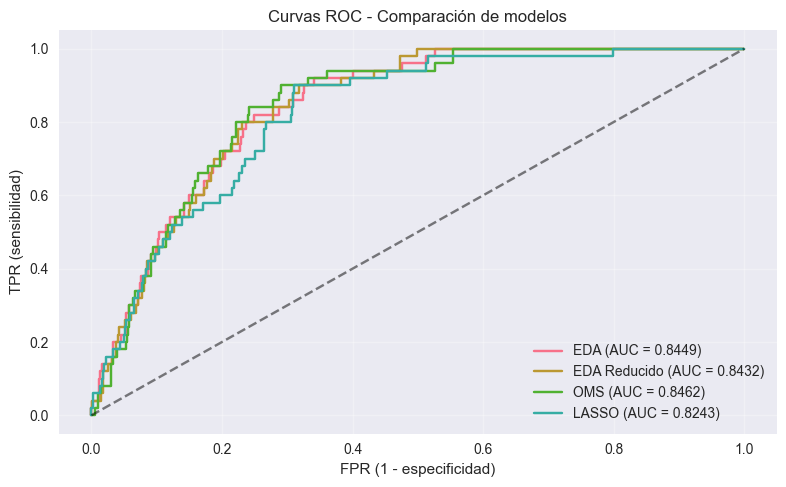

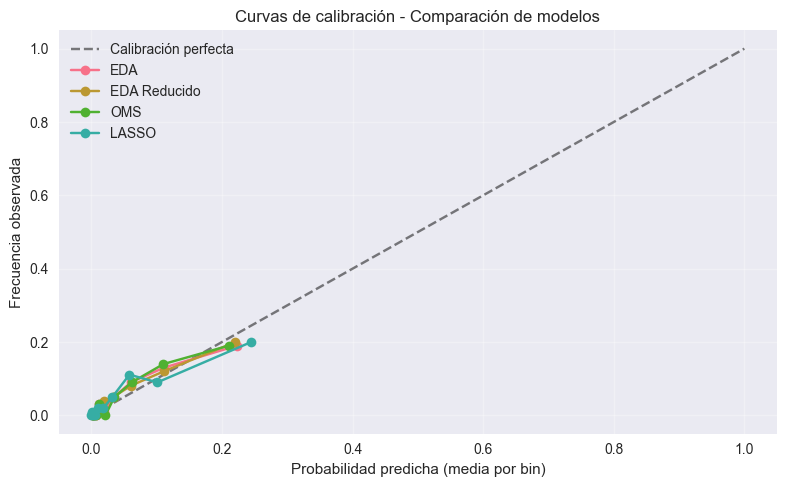

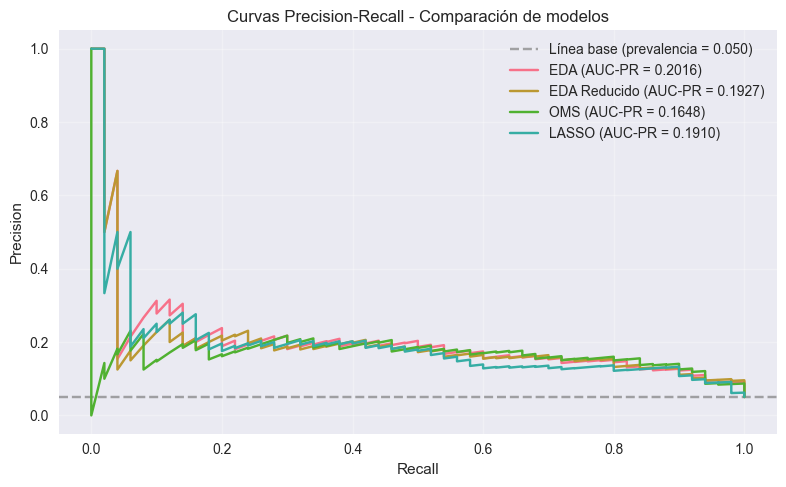

                  AIC      BIC  Pseudo R²  AUC-ROC  AUC-PR   Brier  Log-loss
Modelo                                                                      
EDA           1282.03  1414.12     0.2125   0.8449  0.2016  0.0435    0.1588
EDA Reducido  1277.23  1384.16     0.2105   0.8432  0.1927  0.0439    0.1603
OMS           1276.80  1352.28     0.2044   0.8462  0.1648  0.0443    0.1599
LASSO         1323.84  1776.73     0.2507   0.8243  0.1910  0.0447    0.1665


In [66]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
from sklearn.calibration import calibration_curve

# Predicciones de cada modelo sobre test (df_test_std definido en 6.1)
modelos = {
    'EDA':          modelo_eda,
    'EDA Reducido': modelo_eda_reducido,
    'OMS':          modelo_oms,
    'LASSO':        modelo_lasso_final
}

y_true = df_test_std['stroke'].values
predicciones = {nombre: m.predict(df_test_std) for nombre, m in modelos.items()}

# --- 1. Curvas ROC superpuestas ---
plt.figure(figsize=(8, 5))
for nombre, probs in predicciones.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val = roc_auc_score(y_true, probs)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('FPR (1 - especificidad)')
plt.ylabel('TPR (sensibilidad)')
plt.title('Curvas ROC - Comparación de modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Curvas de calibración superpuestas ---
plt.figure(figsize=(8, 5))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
for nombre, probs in predicciones.items():
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=10, strategy='quantile')
    plt.plot(prob_pred, prob_true, 'o-', label=nombre)
plt.xlabel('Probabilidad predicha (media por bin)')
plt.ylabel('Frecuencia observada')
plt.title('Curvas de calibración - Comparación de modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. Curvas PR superpuestas ---
plt.figure(figsize=(8, 5))
plt.axhline(y=y_true.mean(), color='gray', linestyle='--', alpha=0.7,
            label=f'Línea base (prevalencia = {y_true.mean():.3f})')
for nombre, probs in predicciones.items():
    prec, rec, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(rec, prec)
    plt.plot(rec, prec, label=f'{nombre} (AUC-PR = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall - Comparación de modelos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. Tabla comparativa ---
from sklearn.metrics import brier_score_loss, log_loss

filas = []
for nombre, m in modelos.items():
    probs = predicciones[nombre]
    filas.append({
        'Modelo':      nombre,
        'AIC':         round(m.aic, 2),
        'BIC':         round(m.bic, 2),
        'Pseudo R²':   round(m.prsquared, 4),
        'AUC-ROC':     round(roc_auc_score(y_true, probs), 4),
        'AUC-PR':      round(auc(*precision_recall_curve(y_true, probs)[1::-1]), 4),
        'Brier':       round(brier_score_loss(y_true, probs), 4),
        'Log-loss':    round(log_loss(y_true, probs), 4),
    })

tabla = pd.DataFrame(filas).set_index('Modelo')
print(tabla)

In [67]:
# Verificar predicciones de cada modelo
for nombre, m in modelos.items():
    probs = predicciones[nombre]
    print(f"{nombre}:")
    print(f"  Min: {probs.min():.4f}, Max: {probs.max():.4f}, Media: {probs.mean():.4f}")
    print(f"  % predicciones > 0.9: {(probs > 0.9).mean()*100:.1f}%")
    print(f"  % predicciones < 0.1: {(probs < 0.1).mean()*100:.1f}%")
    print()

EDA:
  Min: 0.0006, Max: 0.5749, Media: 0.0476
  % predicciones > 0.9: 0.0%
  % predicciones < 0.1: 83.1%

EDA Reducido:
  Min: 0.0010, Max: 0.6222, Media: 0.0474
  % predicciones > 0.9: 0.0%
  % predicciones < 0.1: 83.4%

OMS:
  Min: 0.0005, Max: 0.4519, Media: 0.0468
  % predicciones > 0.9: 0.0%
  % predicciones < 0.1: 83.4%

LASSO:
  Min: 0.0000, Max: 0.6997, Media: 0.0475
  % predicciones > 0.9: 0.0%
  % predicciones < 0.1: 85.5%



**Conclusiones de la comparación:**

- **OMS** tiene el AIC y BIC más bajos (parsimonia con buen ajuste), la AUC-ROC más alta (0.846) y todas sus variables tienen justificación clínica directa (factores de riesgo OMS).
- **EDA** y **EDA Reducido** son competitivos: AUC-PR, Brier y Log-loss son ligeramente mejores en EDA, pero la diferencia es pequeña (≈0.001 en Brier, ≈0.04 en AUC-PR).
- **LASSO** (refit sin penalización sobre las variables retenidas) es claramente el peor: BIC mucho más alto, AUC-ROC más baja y Brier ligeramente peor. La gran cantidad de interacciones que el L1 dejó dentro no se traduce en ganancia predictiva.

**Se selecciona el modelo OMS** por parsimonia, mejor AUC-ROC e interpretabilidad clínica. La pérdida marginal en proper scoring rules (Brier, Log-loss) frente al modelo EDA se considera aceptable a cambio de un modelo con muchas menos variables y motivación sustantiva.


## 8) Análisis y diagnóstico del modelo

### Resultados del modelo

        Logit Marginal Effects       
Dep. Variable:                 stroke
Method:                          dydx
At:                              mean
                                        dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
age                                    0.0328      0.005      7.142      0.000       0.024       0.042
avg_glucose_level                      0.0037      0.001      3.191      0.001       0.001       0.006
bmi                                    0.0014      0.002      0.877      0.381      -0.002       0.005
hypertension_1                         0.0091      0.003      2.676      0.007       0.002       0.016
smoking_status_formerly_smoked         0.0135      0.008      1.783      0.075      -0.001       0.028
smoking_status_smokes                  0.0163      0.007      2.301      0.021       0.002       0.030
smoking_status_Unknown  

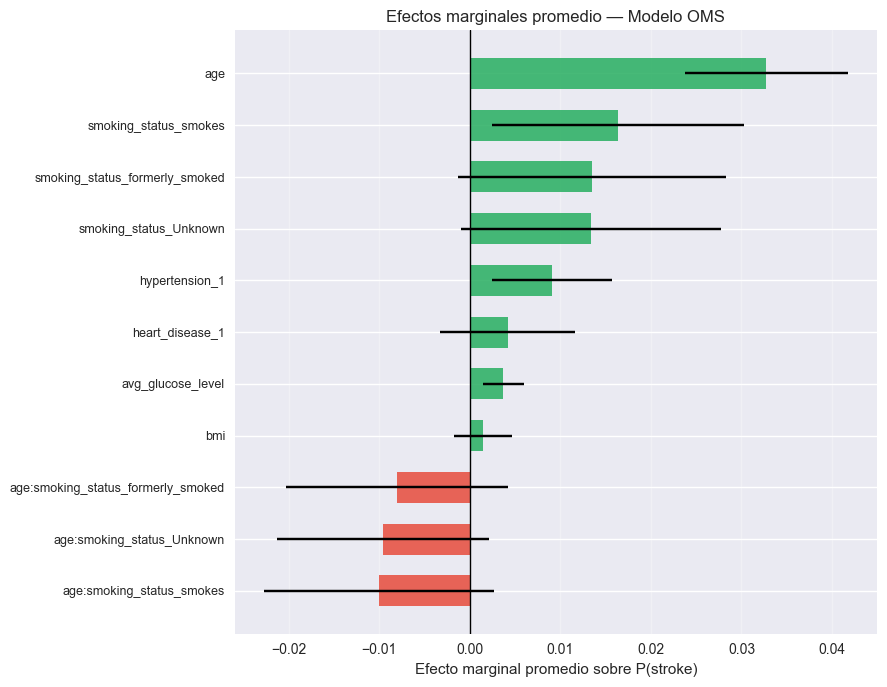

In [68]:
from statsmodels.discrete.discrete_model import LogitResults

# Efectos marginales promedio (Average Marginal Effects)
marginal_effects = modelo_oms.get_margeff(at='mean')
print(marginal_effects.summary())

# Extraer valores para graficar
me = marginal_effects.margeff
me_se = marginal_effects.margeff_se
nombres = marginal_effects.summary_frame().index

# Intervalos de confianza
ic_low = me - 1.96 * me_se
ic_up  = me + 1.96 * me_se
pvals  = marginal_effects.pvalues


# Extraer valores para graficar
summary_me = marginal_effects.summary_frame()

# Ordenar por magnitud del efecto marginal
summary_me = summary_me.sort_values('dy/dx')

me_ord     = summary_me['dy/dx'].values
ic_low_ord = summary_me['Conf. Int. Low'].values
ic_up_ord  = summary_me['Cont. Int. Hi.'].values
pvals_ord  = summary_me['Pr(>|z|)'].values
nombres_ord = summary_me.index

colores = ['#e74c3c' if v < 0 else '#27ae60' for v in me_ord]

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(range(len(me_ord)), me_ord,
        xerr=[me_ord - ic_low_ord, ic_up_ord - me_ord],
        color=colores, alpha=0.85, capsize=4, height=0.6)

ax.axvline(x=0, color='black', linewidth=1)
ax.set_yticks(range(len(me_ord)))
ax.set_yticklabels(nombres_ord, fontsize=9)
ax.set_xlabel('Efecto marginal promedio sobre P(stroke)')
ax.set_title('Efectos marginales promedio — Modelo OMS')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Tabla de métricas globales ──────────────────────────────────────────
metricas = pd.DataFrame({
    'Métrica': ['AIC', 'BIC', 'Log-verosimilitud', 'Pseudo R² (McFadden)', 'LLR p-value'],
    'Valor':   [
        round(modelo_oms.aic, 2),
        round(modelo_oms.bic, 2),
        round(modelo_oms.llf, 2),
        round(modelo_oms.prsquared, 4),
        f"{modelo_oms.llr_pvalue:.2e}"
    ]
})
print(metricas.to_string(index=False))

             Métrica    Valor
                 AIC   1276.8
                 BIC  1352.28
   Log-verosimilitud   -626.4
Pseudo R² (McFadden)   0.2044
         LLR p-value 2.11e-62


### Revisión de multicolinealidad

In [70]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# ── 1. VIF clásico (sobre X, ignora pesos del GLM) ────────────────────────
y_vec, X_design = dmatrices(formula_oms, data=df_train_unbal_std, return_type='dataframe')

vif_classic = pd.DataFrame({
    'variable':    X_design.columns,
    'VIF_classic': [variance_inflation_factor(X_design.values, i)
                    for i in range(X_design.shape[1])]
})
print('VIF clásico (sobre X, ignora pesos del GLM):')
print(vif_classic.round(3))

# ── 2. VIF ponderado GLM (sobre W^{1/2} X) ────────────────────────────────
mu_hat = modelo_oms.predict(df_train_unbal_std)
w      = mu_hat * (1 - mu_hat)
W_sqrt = np.sqrt(w.values)
X_w    = X_design.values * W_sqrt[:, None]
X_w_df = pd.DataFrame(X_w, columns=X_design.columns)

vif_glm = pd.DataFrame({
    'variable':        X_w_df.columns,
    'VIF_GLM_weighted': [variance_inflation_factor(X_w_df.values, i)
                         for i in range(X_w_df.shape[1])]
})
print('\nVIF basado en X^T W X (apropiado para GLM):')
print(vif_glm.round(3))

vif_combined = vif_classic.merge(vif_glm, on='variable')
print('\nComparación clásico vs ponderado:')
print(vif_combined.round(3))

# ── 3. GVIF (Fox-Monette) para variables categóricas ──────────────────────
def gvif_grouped(X, group_cols):
    """
    GVIF para un grupo de columnas (dummies de la misma variable categórica).
    Se aplica sobre la sub-matriz sin intercepto.
    """
    cols = list(X.columns)
    if 'Intercept' in cols:
        cols = [c for c in cols if c != 'Intercept']
    Xs     = X[cols]
    R      = Xs.corr().values
    idx_g  = [cols.index(c) for c in group_cols]
    idx_ng = [i for i in range(len(cols)) if i not in idx_g]
    R_gg   = R[np.ix_(idx_g,  idx_g)]
    R_nn   = R[np.ix_(idx_ng, idx_ng)]
    detR   = np.linalg.det(R)
    gvif   = (np.linalg.det(R_gg) * np.linalg.det(R_nn)) / detR
    df_g   = len(group_cols)
    return gvif, df_g, gvif ** (1 / (2 * df_g))

VIF clásico (sobre X, ignora pesos del GLM):
                              variable  VIF_classic
0                            Intercept        3.012
1                                  age        3.847
2                    avg_glucose_level        1.103
3                                  bmi        1.295
4                       hypertension_1        1.126
5       smoking_status_formerly_smoked        1.605
6                smoking_status_smokes        1.262
7               smoking_status_Unknown        1.509
8                      heart_disease_1        1.096
9   age:smoking_status_formerly_smoked        1.883
10           age:smoking_status_smokes        1.348
11          age:smoking_status_Unknown        2.889

VIF basado en X^T W X (apropiado para GLM):
                              variable  VIF_GLM_weighted
0                            Intercept            16.979
1                                  age            14.742
2                    avg_glucose_level             1.286
3     

In [71]:
# Definir grupos de variables para la GVIF según la fórmula del modelo OMS
vars_individuales = ['age', 'avg_glucose_level', 'bmi', 'hypertension_1', 'heart_disease_1']
grupo_smoking = ['smoking_status_formerly_smoked', 'smoking_status_smokes', 'smoking_status_Unknown']
grupo_age_smoking = ['age:smoking_status_formerly_smoked', 'age:smoking_status_smokes', 'age:smoking_status_Unknown']

# Tabla GVIF completa
gvif_rows = []

# Variables individuales (df=1)
for var in vars_individuales:
    vif_val = vif_classic[vif_classic['variable'] == var]['VIF_classic'].values[0]
    gvif_adj = np.sqrt(vif_val)
    gvif_rows.append({
        'Variable': var,
        'df': 1,
        'GVIF': round(vif_val, 4),
        'GVIF^(1/(2df))': round(gvif_adj, 4)
    })

# Grupos categóricos (df>1)
grupos = {
    'smoking_status':     grupo_smoking,
    'age:smoking_status': grupo_age_smoking
}

for nombre, grupo in grupos.items():
    gvif_val, dfc, gvif_adj = gvif_grouped(X_design, grupo)
    gvif_rows.append({
        'Variable': nombre,
        'df': dfc,
        'GVIF': round(gvif_val, 4),
        'GVIF^(1/(2df))': round(gvif_adj, 4)
    })

df_gvif = pd.DataFrame(gvif_rows).sort_values('GVIF^(1/(2df))', ascending=False)
df_gvif.index = range(1, len(df_gvif) + 1)

print("Tabla GVIF completa — Modelo OMS")
print(df_gvif.to_string())
print(f"\nReferencia: GVIF^(1/(2df)) > sqrt(5) ≈ 2.24 indica preocupación")
print(f"Número de condición de Belsley: 4.15 ")

Tabla GVIF completa — Modelo OMS
             Variable  df    GVIF  GVIF^(1/(2df))
1                 age   1  3.8475          1.9615
2  age:smoking_status   3  5.4395          1.3262
3                 bmi   1  1.2951          1.1380
4      smoking_status   3  1.7664          1.0995
5      hypertension_1   1  1.1256          1.0609
6   avg_glucose_level   1  1.1034          1.0504
7     heart_disease_1   1  1.0956          1.0467

Referencia: GVIF^(1/(2df)) > sqrt(5) ≈ 2.24 indica preocupación
Número de condición de Belsley: 4.15 
